In [265]:
from __future__ import annotations

from pathlib import Path
import os
import warnings
import requests
from pathlib import Path

import pandas as pd
import numpy as np
import re
import math

import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from typing import Optional, Tuple, Dict
from datetime import datetime


warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.2f}'.format

# 한글 및 마이너스 깨짐 방지
try:
    mpl.rcParams["font.family"] = "Malgun Gothic"   # Windows
except:
    mpl.rcParams["font.family"] = "AppleGothic"    # Mac

mpl.rcParams["axes.unicode_minus"] = False

# 경쟁업체_방문자_숙박수요_전처리_진원.ipynb

# 숙박업/관광숙박업

## 관광숙박업

In [266]:
#관광숙박업 인허가 파일 불러오기
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_관광숙박업_인허가_정보.csv")

hotel = pd.read_csv(DATA_DIR, index_col=0)

In [267]:
hotel

,상세영업상태명,도로명전체주소,사업장명,문화체육업종명,좌표정보x(epsg5174),좌표정보y(epsg5174),지역구분명,지상층수,지하층수,객실수,주변환경명,건물용도명,시설면적,관광숙박업상세명
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,관광숙박업,202833.26,440511.56,자연녹지지역,11.00,1.00,250.00,주택가주변,호텔,52135.75,관광호텔업
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,관광숙박업,190265.52,442043.31,준공업지역,9.00,1.00,29.00,기타,숙박시설,755.34,호스텔업
2,휴업,서울특별시 강북구 도봉로 16 (미아동),호텔 빅토리아,관광숙박업,202651.54,456473.89,상업지역,0.00,0.00,0.00,유흥업소밀집지역,환경위생시설,0.00,관광호텔업
3,휴업,서울특별시 강북구 4.19로 135 (수유동),호텔더숲아카데미하우스,관광숙박업,200020.57,459790.39,NaN,0.00,0.00,0.00,NaN,NaN,0.00,관광호텔업
4,휴업,서울특별시 강북구 덕릉로 111 (번동),쏠라리움씨티,관광숙박업,202232.20,459201.47,NaN,0.00,0.00,0.00,NaN,NaN,0.00,호스텔업
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,직권말소,서울특별시 영등포구 버드나루로 23 (영등포동2가),라스베가스관광호텔,관광숙박업,192165.93,446508.00,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN
758,직권말소,서울특별시 영등포구 은행로 62 (여의도동),여의도관광호텔,관광숙박업,193321.89,447552.08,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN
759,직권말소,서울특별시 영등포구 국회대로76길 16 (여의도동),맨하탄호텔터키베스,관광숙박업,193019.65,447560.16,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN
760,직권말소,서울특별시 영등포구 은행로 62 (여의도동),여의도관광(칵테일바),관광숙박업,193321.89,447552.08,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN


In [268]:
# 영업 상태 필터링: '폐업'과 '직권말소'를 모두 제외
exclude_list = ['폐업', '직권말소', '등록취소']
hotel_filtered = hotel[~hotel['상세영업상태명'].isin(exclude_list)]

# 폐업 및 직권말소는 현행법에 저촉되기 때문에 행정처분받은 것으로 판단됨

In [269]:
hotel_filtered

,상세영업상태명,도로명전체주소,사업장명,문화체육업종명,좌표정보x(epsg5174),좌표정보y(epsg5174),지역구분명,지상층수,지하층수,객실수,주변환경명,건물용도명,시설면적,관광숙박업상세명
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,관광숙박업,202833.26,440511.56,자연녹지지역,11.00,1.00,250.00,주택가주변,호텔,52135.75,관광호텔업
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,관광숙박업,190265.52,442043.31,준공업지역,9.00,1.00,29.00,기타,숙박시설,755.34,호스텔업
2,휴업,서울특별시 강북구 도봉로 16 (미아동),호텔 빅토리아,관광숙박업,202651.54,456473.89,상업지역,0.00,0.00,0.00,유흥업소밀집지역,환경위생시설,0.00,관광호텔업
3,휴업,서울특별시 강북구 4.19로 135 (수유동),호텔더숲아카데미하우스,관광숙박업,200020.57,459790.39,NaN,0.00,0.00,0.00,NaN,NaN,0.00,관광호텔업
4,휴업,서울특별시 강북구 덕릉로 111 (번동),쏠라리움씨티,관광숙박업,202232.20,459201.47,NaN,0.00,0.00,0.00,NaN,NaN,0.00,호스텔업
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,영업중,"서울특별시 중구 남대문로5길 23, 세창빌딩 2층 (북창동)",올스테이 호스텔,관광숙박업,198068.13,451126.47,상업지역,2.00,0.00,11.00,NaN,숙박시설,175.21,호스텔업
739,영업중,"서울특별시 종로구 종로46길 1, 4, 5층 (창신동)",케이스테이,관광숙박업,200899.71,452134.55,일반상업지역,0.00,0.00,27.00,기타,숙박시설,498.24,호스텔업
740,영업중,"서울특별시 중구 명동10길 19-27, 디자이너스빌딩 (명동2가)",블루닷 포쉬텔,관광숙박업,198678.77,451209.55,중심상업지역,0.00,0.00,51.00,NaN,NaN,1554.41,호스텔업
741,영업중,서울특별시 중구 퇴계로18길 49 (남산동2가),다두하우스,관광숙박업,198586.95,450721.93,일반주거지역,0.00,0.00,8.00,NaN,NaN,274.68,호스텔업


In [270]:
#불필요 컬럼 제거
# '문화체육업종명', '지역구분명', '지상층수', '지하층수', '객실수', '주변환경명', '시설면적', '건물용도명' 컬럼 제외
# 제외되는 컬럼들에는 0.0과 같은 결측치가 반 이상을 차지함
hotel_cleaned = hotel_filtered.drop(columns=['문화체육업종명', '지역구분명', '지상층수', '지하층수', '객실수', '주변환경명', '시설면적', '건물용도명'])

# 결과 확인
hotel_cleaned.head()

,상세영업상태명,도로명전체주소,사업장명,좌표정보x(epsg5174),좌표정보y(epsg5174),관광숙박업상세명
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,202833.26,440511.56,관광호텔업
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,190265.52,442043.31,호스텔업
2,휴업,서울특별시 강북구 도봉로 16 (미아동),호텔 빅토리아,202651.54,456473.89,관광호텔업
3,휴업,서울특별시 강북구 4.19로 135 (수유동),호텔더숲아카데미하우스,200020.57,459790.39,관광호텔업
4,휴업,서울특별시 강북구 덕릉로 111 (번동),쏠라리움씨티,202232.20,459201.47,호스텔업


In [271]:
#GeoDataFrame으로 변환
geometry = gpd.points_from_xy(
    hotel_cleaned['좌표정보x(epsg5174)'],
    hotel_cleaned['좌표정보y(epsg5174)']
)

hotel_cleaned_5174 = gpd.GeoDataFrame(
    hotel_cleaned,
    geometry=geometry,
    crs="EPSG:5174"
)

hotel_cleaned_5179 = hotel_cleaned_5174.to_crs(epsg=5179)

In [272]:
hotel_cleaned_5179.head()

,상세영업상태명,도로명전체주소,사업장명,좌표정보x(epsg5174),좌표정보y(epsg5174),관광숙박업상세명,geometry
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,202833.26,440511.56,관광호텔업,POINT (958687.131 1940942.531)
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,190265.52,442043.31,호스텔업,POINT (946132.449 1942540.17)
2,휴업,서울특별시 강북구 도봉로 16 (미아동),호텔 빅토리아,202651.54,456473.89,관광호텔업,POINT (958590.064 1956899.413)
3,휴업,서울특별시 강북구 4.19로 135 (수유동),호텔더숲아카데미하우스,200020.57,459790.39,관광호텔업,POINT (955977.758 1960228.556)
4,휴업,서울특별시 강북구 덕릉로 111 (번동),쏠라리움씨티,202232.20,459201.47,호스텔업,POINT (958185.374 1959628.128)


In [273]:

# 좌표정보(espg5179) 추가
# 1. 좌표 변환을 위한 Transformer 설정 (EPSG:5174 -> EPSG:5179)
# always_xy=True를 설정해야 x(경도), y(위도) 순서가 유지됨.
transformer = Transformer.from_crs("epsg:5174", "epsg:5179", always_xy=True)

# 2. 좌표 변환 함수 정의
def convert_coords(row):
    # x, y 컬럼 값을 가져와서 변환
    new_x, new_y = transformer.transform(row['좌표정보x(epsg5174)'], row['좌표정보y(epsg5174)'])
    return pd.Series([new_x, new_y])

# 3. 데이터프레임에 적용하여 새로운 컬럼 생성
hotel_cleaned_5179[['좌표정보x(epsg5179)', '좌표정보y(epsg5179)']] = hotel_cleaned_5179.apply(convert_coords, axis=1)

# 4. 결과 확인
print(hotel_cleaned_5179[['사업장명', '좌표정보x(epsg5179)', '좌표정보y(epsg5179)']].head())

                   사업장명  좌표정보x(epsg5179)  좌표정보y(epsg5179)
0  더케이호텔앤리조트(주) 더케이호텔서울        958687.13       1940942.53
1                스토리호스텔        946132.45       1942540.17
2               호텔 빅토리아        958590.06       1956899.41
3           호텔더숲아카데미하우스        955977.76       1960228.56
4                쏠라리움씨티        958185.37       1959628.13


In [274]:
hotel_cleaned_5179.head()

,상세영업상태명,도로명전체주소,사업장명,좌표정보x(epsg5174),좌표정보y(epsg5174),관광숙박업상세명,geometry,좌표정보x(epsg5179),좌표정보y(epsg5179)
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,202833.26,440511.56,관광호텔업,POINT (958687.131 1940942.531),958687.13,1940942.53
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,190265.52,442043.31,호스텔업,POINT (946132.449 1942540.17),946132.45,1942540.17
2,휴업,서울특별시 강북구 도봉로 16 (미아동),호텔 빅토리아,202651.54,456473.89,관광호텔업,POINT (958590.064 1956899.413),958590.06,1956899.41
3,휴업,서울특별시 강북구 4.19로 135 (수유동),호텔더숲아카데미하우스,200020.57,459790.39,관광호텔업,POINT (955977.758 1960228.556),955977.76,1960228.56
4,휴업,서울특별시 강북구 덕릉로 111 (번동),쏠라리움씨티,202232.20,459201.47,호스텔업,POINT (958185.374 1959628.128),958185.37,1959628.13


In [275]:
# 컬럼 이름 변경 (dictionary 형태를 사용하여 {기존이름: 바꿀이름} 지정)
hotel_cleaned_5179 = hotel_cleaned_5179.rename(columns={
    '좌표정보x(epsg5179)': 'X좌표(GRS80TM)',
    '좌표정보y(epsg5179)': 'Y좌표(GRS80TM)',
    '좌표정보x(epsg5174)': 'X좌표(Bessel)',
    '좌표정보y(epsg5174)': 'Y좌표(Bessel)'
})

# 결과 확인
print(hotel_cleaned_5179.columns)

Index(['상세영업상태명', '도로명전체주소', '사업장명', 'X좌표(Bessel)', 'Y좌표(Bessel)', '관광숙박업상세명',
       'geometry', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)'],
      dtype='object')


In [276]:
hotel_4326 = hotel_cleaned_5179.to_crs(epsg=4326)

# 위경도 컬럼 추가
hotel_cleaned_5179["X좌표(WGS84)"] = hotel_4326.geometry.x
hotel_cleaned_5179["Y좌표(WGS84)"] = hotel_4326.geometry.y

In [277]:
hotel_cleaned_5179.head()

,상세영업상태명,도로명전체주소,사업장명,X좌표(Bessel),Y좌표(Bessel),관광숙박업상세명,geometry,X좌표(GRS80TM),Y좌표(GRS80TM),X좌표(WGS84),Y좌표(WGS84)
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,202833.26,440511.56,관광호텔업,POINT (958687.131 1940942.531),958687.13,1940942.53,127.03,37.47
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,190265.52,442043.31,호스텔업,POINT (946132.449 1942540.17),946132.45,1942540.17,126.89,37.48
2,휴업,서울특별시 강북구 도봉로 16 (미아동),호텔 빅토리아,202651.54,456473.89,관광호텔업,POINT (958590.064 1956899.413),958590.06,1956899.41,127.03,37.61
3,휴업,서울특별시 강북구 4.19로 135 (수유동),호텔더숲아카데미하우스,200020.57,459790.39,관광호텔업,POINT (955977.758 1960228.556),955977.76,1960228.56,127.00,37.64
4,휴업,서울특별시 강북구 덕릉로 111 (번동),쏠라리움씨티,202232.20,459201.47,호스텔업,POINT (958185.374 1959628.128),958185.37,1959628.13,127.03,37.64


In [278]:
# 컬럼 순서 조정
hotel_cleaned_5179 = hotel_cleaned_5179[['상세영업상태명', '도로명전체주소', '사업장명', '관광숙박업상세명', 'X좌표(Bessel)', 'Y좌표(Bessel)',
                                         'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry']]

In [279]:
hotel_cleaned_5179.head()

,상세영업상태명,도로명전체주소,사업장명,관광숙박업상세명,X좌표(Bessel),Y좌표(Bessel),X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,관광호텔업,202833.26,440511.56,127.03,37.47,958687.13,1940942.53,POINT (958687.131 1940942.531)
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,호스텔업,190265.52,442043.31,126.89,37.48,946132.45,1942540.17,POINT (946132.449 1942540.17)
2,휴업,서울특별시 강북구 도봉로 16 (미아동),호텔 빅토리아,관광호텔업,202651.54,456473.89,127.03,37.61,958590.06,1956899.41,POINT (958590.064 1956899.413)
3,휴업,서울특별시 강북구 4.19로 135 (수유동),호텔더숲아카데미하우스,관광호텔업,200020.57,459790.39,127.00,37.64,955977.76,1960228.56,POINT (955977.758 1960228.556)
4,휴업,서울특별시 강북구 덕릉로 111 (번동),쏠라리움씨티,호스텔업,202232.20,459201.47,127.03,37.64,958185.37,1959628.13,POINT (958185.374 1959628.128)


## 일반숙박업

### 숙박업 인허가 파일 불러오기

In [280]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_숙박업_인허가_정보.csv")

motel = pd.read_csv(DATA_DIR, index_col=0)

In [281]:
motel

,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,상세영업상태명,...,한실수,양실수,조건부허가신고사유,조건부허가시작일자,조건부허가종료일자,건물소유구분명,여성종사자수,남성종사자수,다중이용업소여부,Unnamed: 44
0,숙박업,03_11_03_P,3120000,3120000-201-1997-00022,1997-06-11,NaN,1,영업/정상,1,영업,...,0.00,35.00,NaN,NaN,NaN,자가,0.00,0.00,N,NaN
1,숙박업,03_11_03_P,3010000,3010000-201-2003-00050,1968-01-26,NaN,1,영업/정상,1,영업,...,0.00,15.00,NaN,NaN,NaN,자가,0.00,0.00,N,NaN
2,숙박업,03_11_03_P,3230000,3230000-201-1988-00038,2003-02-27,NaN,1,영업/정상,1,영업,...,13.00,17.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
3,숙박업,03_11_03_P,3180000,3180000-201-2003-00007,2003-02-26,NaN,1,영업/정상,1,영업,...,0.00,20.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
4,숙박업,03_11_03_P,3010000,3010000-201-1968-00106,1968-01-10,NaN,1,영업/정상,1,영업,...,0.00,11.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6894,숙박업,03_11_03_P,3020000,3020000-201-2000-00272,2000-10-30,NaN,3,폐업,2,폐업,...,7.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
6895,숙박업,03_11_03_P,3120000,3120000-201-1970-01208,1970-07-27,NaN,3,폐업,2,폐업,...,10.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
6896,숙박업,03_11_03_P,3020000,3020000-201-2002-00044,2002-12-31,NaN,3,폐업,2,폐업,...,18.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
6897,숙박업,03_11_03_P,3230000,3230000-201-2006-00001,2006-10-13,NaN,3,폐업,2,폐업,...,0.00,39.00,NaN,NaN,NaN,자가,0.00,0.00,N,NaN


### 영업상태 필터링

In [282]:
# '폐업'과 '직권말소'를 모두 제외
exclude_list_m = ['폐업', '직권말소', '등록취소']
motel_filtered = motel[~motel['상세영업상태명'].isin(exclude_list)]

In [283]:
motel_filtered.head()

,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,상세영업상태명,...,한실수,양실수,조건부허가신고사유,조건부허가시작일자,조건부허가종료일자,건물소유구분명,여성종사자수,남성종사자수,다중이용업소여부,Unnamed: 44
0,숙박업,03_11_03_P,3120000,3120000-201-1997-00022,1997-06-11,NaN,1,영업/정상,1,영업,...,0.00,35.00,NaN,NaN,NaN,자가,0.00,0.00,N,NaN
1,숙박업,03_11_03_P,3010000,3010000-201-2003-00050,1968-01-26,NaN,1,영업/정상,1,영업,...,0.00,15.00,NaN,NaN,NaN,자가,0.00,0.00,N,NaN
2,숙박업,03_11_03_P,3230000,3230000-201-1988-00038,2003-02-27,NaN,1,영업/정상,1,영업,...,13.00,17.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
3,숙박업,03_11_03_P,3180000,3180000-201-2003-00007,2003-02-26,NaN,1,영업/정상,1,영업,...,0.00,20.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN
4,숙박업,03_11_03_P,3010000,3010000-201-1968-00106,1968-01-10,NaN,1,영업/정상,1,영업,...,0.00,11.00,NaN,NaN,NaN,NaN,0.00,0.00,N,NaN


### 불필요 컬럼 제거

In [284]:
# 관광숙박업 데이터와 동일한 컬럼으로 통일
motel_subset = motel_filtered[['상세영업상태명', '소재지전체주소', '도로명전체주소', '사업장명', '좌표정보x(epsg5174)', '좌표정보y(epsg5174)', '위생업태명']]

In [285]:
motel_subset.head()

,상세영업상태명,소재지전체주소,도로명전체주소,사업장명,좌표정보x(epsg5174),좌표정보y(epsg5174),위생업태명
0,영업,서울특별시 서대문구 창천동 20-37,서울특별시 서대문구 연세로2길 50 (창천동),URBAN HOTEL&PLAY(구 아바니호텔),194597.94,450471.90,여관업
1,영업,서울특별시 중구 신당동 366-101번지,서울특별시 중구 다산로 66 (신당동),세화장여관,200624.71,449784.76,여관업
2,영업,서울특별시 송파구 방이동 41-5,서울특별시 송파구 올림픽로34길 5 (방이동),IMT 모텔,209723.68,445996.93,여관업
3,영업,서울특별시 영등포구 영등포동3가 24,서울특별시 영등포구 영등포로46길 7-6 (영등포동3가),별빛호텔(별),191808.03,446252.59,여관업
4,영업,서울특별시 중구 회현동1가 127-2번지,서울특별시 중구 퇴계로12길 45-1 (회현동1가),동원여관,198314.29,450598.30,여관업


### 컬럼명 통일

In [286]:
# '위생업태명'을 '숙박업상세명'으로 변경
motel_subset.rename(columns={'위생업태명': '숙박업상세명'}, inplace=True)

In [287]:
motel_subset.head()

,상세영업상태명,소재지전체주소,도로명전체주소,사업장명,좌표정보x(epsg5174),좌표정보y(epsg5174),숙박업상세명
0,영업,서울특별시 서대문구 창천동 20-37,서울특별시 서대문구 연세로2길 50 (창천동),URBAN HOTEL&PLAY(구 아바니호텔),194597.94,450471.90,여관업
1,영업,서울특별시 중구 신당동 366-101번지,서울특별시 중구 다산로 66 (신당동),세화장여관,200624.71,449784.76,여관업
2,영업,서울특별시 송파구 방이동 41-5,서울특별시 송파구 올림픽로34길 5 (방이동),IMT 모텔,209723.68,445996.93,여관업
3,영업,서울특별시 영등포구 영등포동3가 24,서울특별시 영등포구 영등포로46길 7-6 (영등포동3가),별빛호텔(별),191808.03,446252.59,여관업
4,영업,서울특별시 중구 회현동1가 127-2번지,서울특별시 중구 퇴계로12길 45-1 (회현동1가),동원여관,198314.29,450598.30,여관업


### GeoDataFrame으로 변환

In [288]:
geometry = gpd.points_from_xy(
    motel_subset['좌표정보x(epsg5174)'],
    motel_subset['좌표정보y(epsg5174)']
)

motel_subset_5174 = gpd.GeoDataFrame(
    motel_subset,
    geometry=geometry,
    crs="EPSG:5174"
)

motel_subset_5179 = motel_subset_5174.to_crs(epsg=5179)

In [289]:
motel_subset_5179.head()

,상세영업상태명,소재지전체주소,도로명전체주소,사업장명,좌표정보x(epsg5174),좌표정보y(epsg5174),숙박업상세명,geometry
0,영업,서울특별시 서대문구 창천동 20-37,서울특별시 서대문구 연세로2길 50 (창천동),URBAN HOTEL&PLAY(구 아바니호텔),194597.94,450471.90,여관업,POINT (950507.827 1950942.526)
1,영업,서울특별시 중구 신당동 366-101번지,서울특별시 중구 다산로 66 (신당동),세화장여관,200624.71,449784.76,여관업,POINT (956528.567 1950223.714)
2,영업,서울특별시 송파구 방이동 41-5,서울특별시 송파구 올림픽로34길 5 (방이동),IMT 모텔,209723.68,445996.93,여관업,POINT (965603.799 1946389.21)
3,영업,서울특별시 영등포구 영등포동3가 24,서울특별시 영등포구 영등포로46길 7-6 (영등포동3가),별빛호텔(별),191808.03,446252.59,여관업,POINT (947696.642 1946739.649)
4,영업,서울특별시 중구 회현동1가 127-2번지,서울특별시 중구 퇴계로12길 45-1 (회현동1가),동원여관,198314.29,450598.30,여관업,POINT (954223.379 1951049.175)


### 좌표정보(espg5179) 추가

In [290]:
# 1. 좌표 변환을 위한 Transformer 설정 (EPSG:5174 -> EPSG:5179)
# always_xy=True를 설정해야 x(경도), y(위도) 순서가 유지됨.
transformer = Transformer.from_crs("epsg:5174", "epsg:5179", always_xy=True)

# 2. 좌표 변환 함수 정의
def convert_coords(row):
    # x, y 컬럼 값을 가져와서 변환
    new_x, new_y = transformer.transform(row['좌표정보x(epsg5174)'], row['좌표정보y(epsg5174)'])
    return pd.Series([new_x, new_y])

# 3. 데이터프레임에 적용하여 새로운 컬럼 생성
motel_subset_5179[['좌표정보x(epsg5179)', '좌표정보y(epsg5179)']] = motel_subset_5179.apply(convert_coords, axis=1)

# 4. 결과 확인
print(motel_subset_5179[['사업장명', '좌표정보x(epsg5179)', '좌표정보y(epsg5179)']].head())

                        사업장명  좌표정보x(epsg5179)  좌표정보y(epsg5179)
0  URBAN HOTEL&PLAY(구 아바니호텔)        950507.83       1950942.53
1                      세화장여관        956528.57       1950223.71
2                     IMT 모텔        965603.80       1946389.21
3                    별빛호텔(별)        947696.64       1946739.65
4                       동원여관        954223.38       1951049.18


In [291]:
motel_subset_5179.head()

,상세영업상태명,소재지전체주소,도로명전체주소,사업장명,좌표정보x(epsg5174),좌표정보y(epsg5174),숙박업상세명,geometry,좌표정보x(epsg5179),좌표정보y(epsg5179)
0,영업,서울특별시 서대문구 창천동 20-37,서울특별시 서대문구 연세로2길 50 (창천동),URBAN HOTEL&PLAY(구 아바니호텔),194597.94,450471.90,여관업,POINT (950507.827 1950942.526),950507.83,1950942.53
1,영업,서울특별시 중구 신당동 366-101번지,서울특별시 중구 다산로 66 (신당동),세화장여관,200624.71,449784.76,여관업,POINT (956528.567 1950223.714),956528.57,1950223.71
2,영업,서울특별시 송파구 방이동 41-5,서울특별시 송파구 올림픽로34길 5 (방이동),IMT 모텔,209723.68,445996.93,여관업,POINT (965603.799 1946389.21),965603.80,1946389.21
3,영업,서울특별시 영등포구 영등포동3가 24,서울특별시 영등포구 영등포로46길 7-6 (영등포동3가),별빛호텔(별),191808.03,446252.59,여관업,POINT (947696.642 1946739.649),947696.64,1946739.65
4,영업,서울특별시 중구 회현동1가 127-2번지,서울특별시 중구 퇴계로12길 45-1 (회현동1가),동원여관,198314.29,450598.30,여관업,POINT (954223.379 1951049.175),954223.38,1951049.18


### 좌표정보x(epsg5179) -> X좌표(GRS80TM)

In [292]:
# 컬럼 이름 변경 (dictionary 형태를 사용하여 {기존이름: 바꿀이름} 지정)
motel_subset_5179 = motel_subset_5179.rename(columns={
    '좌표정보x(epsg5179)': 'X좌표(GRS80TM)',
    '좌표정보y(epsg5179)': 'Y좌표(GRS80TM)',
    '좌표정보x(epsg5174)': 'X좌표(Bessel)',
    '좌표정보y(epsg5174)': 'Y좌표(Bessel)'
})

# 결과 확인
print(motel_subset_5179.columns)

Index(['상세영업상태명', '소재지전체주소', '도로명전체주소', '사업장명', 'X좌표(Bessel)', 'Y좌표(Bessel)',
       '숙박업상세명', 'geometry', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)'],
      dtype='object')


In [293]:
motel_4326 = motel_subset_5179.to_crs(epsg=4326)

# 위경도 컬럼 추가
motel_subset_5179["X좌표(WGS84)"] = motel_4326.geometry.x
motel_subset_5179["Y좌표(WGS84)"] = motel_4326.geometry.y

In [294]:
motel_subset_5179.head()

,상세영업상태명,소재지전체주소,도로명전체주소,사업장명,X좌표(Bessel),Y좌표(Bessel),숙박업상세명,geometry,X좌표(GRS80TM),Y좌표(GRS80TM),X좌표(WGS84),Y좌표(WGS84)
0,영업,서울특별시 서대문구 창천동 20-37,서울특별시 서대문구 연세로2길 50 (창천동),URBAN HOTEL&PLAY(구 아바니호텔),194597.94,450471.90,여관업,POINT (950507.827 1950942.526),950507.83,1950942.53,126.94,37.56
1,영업,서울특별시 중구 신당동 366-101번지,서울특별시 중구 다산로 66 (신당동),세화장여관,200624.71,449784.76,여관업,POINT (956528.567 1950223.714),956528.57,1950223.71,127.01,37.55
2,영업,서울특별시 송파구 방이동 41-5,서울특별시 송파구 올림픽로34길 5 (방이동),IMT 모텔,209723.68,445996.93,여관업,POINT (965603.799 1946389.21),965603.80,1946389.21,127.11,37.52
3,영업,서울특별시 영등포구 영등포동3가 24,서울특별시 영등포구 영등포로46길 7-6 (영등포동3가),별빛호텔(별),191808.03,446252.59,여관업,POINT (947696.642 1946739.649),947696.64,1946739.65,126.91,37.52
4,영업,서울특별시 중구 회현동1가 127-2번지,서울특별시 중구 퇴계로12길 45-1 (회현동1가),동원여관,198314.29,450598.30,여관업,POINT (954223.379 1951049.175),954223.38,1951049.18,126.98,37.56


### 컬럼 순서 조정

In [295]:
motel_subset_5179 = motel_subset_5179[['상세영업상태명', '소재지전체주소', '도로명전체주소', '사업장명', '숙박업상세명', 'X좌표(Bessel)', 'Y좌표(Bessel)',
                                       'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry']]

In [296]:
motel_subset_5179.head()

,상세영업상태명,소재지전체주소,도로명전체주소,사업장명,숙박업상세명,X좌표(Bessel),Y좌표(Bessel),X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,영업,서울특별시 서대문구 창천동 20-37,서울특별시 서대문구 연세로2길 50 (창천동),URBAN HOTEL&PLAY(구 아바니호텔),여관업,194597.94,450471.90,126.94,37.56,950507.83,1950942.53,POINT (950507.827 1950942.526)
1,영업,서울특별시 중구 신당동 366-101번지,서울특별시 중구 다산로 66 (신당동),세화장여관,여관업,200624.71,449784.76,127.01,37.55,956528.57,1950223.71,POINT (956528.567 1950223.714)
2,영업,서울특별시 송파구 방이동 41-5,서울특별시 송파구 올림픽로34길 5 (방이동),IMT 모텔,여관업,209723.68,445996.93,127.11,37.52,965603.80,1946389.21,POINT (965603.799 1946389.21)
3,영업,서울특별시 영등포구 영등포동3가 24,서울특별시 영등포구 영등포로46길 7-6 (영등포동3가),별빛호텔(별),여관업,191808.03,446252.59,126.91,37.52,947696.64,1946739.65,POINT (947696.642 1946739.649)
4,영업,서울특별시 중구 회현동1가 127-2번지,서울특별시 중구 퇴계로12길 45-1 (회현동1가),동원여관,여관업,198314.29,450598.30,126.98,37.56,954223.38,1951049.18,POINT (954223.379 1951049.175)


## 내/외국인 방문자

## 내국인 자치구별 방문자

### 내국인 방문자 파일 불러오기

In [297]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "자치구별 내외국인 방문자 수 추이.csv")

native_foreigner = pd.read_csv(DATA_DIR, index_col=0)


In [298]:
native_foreigner

,자치구,현지인방문자수,외지인방문자수,외국인방문자수
기준년월,,,,
202501,강남구,15414686.00,17327720.00,436456.00
202501,강동구,7526806.00,4399003.00,36060.00
202501,강북구,3998984.00,2768780.00,24625.00
202501,강서구,7191538.00,6770554.00,215922.00
202501,관악구,6771138.00,5092846.00,54388.00
...,...,...,...,...
202512,용산구,5048106.00,10532053.00,684610.00
202512,은평구,5698878.00,3198626.00,64317.00
202512,종로구,4985428.00,13344258.00,941754.00


### 연/월 분리

In [299]:
# 1. 인덱스를 일반 컬럼으로 변환 (기준년월이 인덱스일 경우 대비)
native_foreigner = native_foreigner.reset_index()

# 2. '기준년월' 컬럼을 문자열 타입으로 변환 (숫자형일 경우 슬라이싱을 위해 필요)
native_foreigner['기준년월'] = native_foreigner['기준년월'].astype(str)

# 3. '년도'와 '월' 컬럼 생성 (슬라이싱)
# '202501' -> '2025' (앞 4자리), '01' (뒤 2자리)
native_foreigner['연도'] = native_foreigner['기준년월'].str[:4]
native_foreigner['월'] = native_foreigner['기준년월'].str[4:]

# 4. 결과 확인
print(native_foreigner.head())

     기준년월  자치구     현지인방문자수     외지인방문자수   외국인방문자수    연도   월
0  202501  강남구 15414686.00 17327720.00 436456.00  2025  01
1  202501  강동구  7526806.00  4399003.00  36060.00  2025  01
2  202501  강북구  3998984.00  2768780.00  24625.00  2025  01
3  202501  강서구  7191538.00  6770554.00 215922.00  2025  01
4  202501  관악구  6771138.00  5092846.00  54388.00  2025  01


In [300]:
native_foreigner

,기준년월,자치구,현지인방문자수,외지인방문자수,외국인방문자수,연도,월
0,202501,강남구,15414686.00,17327720.00,436456.00,2025,01
1,202501,강동구,7526806.00,4399003.00,36060.00,2025,01
2,202501,강북구,3998984.00,2768780.00,24625.00,2025,01
3,202501,강서구,7191538.00,6770554.00,215922.00,2025,01
4,202501,관악구,6771138.00,5092846.00,54388.00,2025,01
...,...,...,...,...,...,...,...
295,202512,용산구,5048106.00,10532053.00,684610.00,2025,12
296,202512,은평구,5698878.00,3198626.00,64317.00,2025,12
297,202512,종로구,4985428.00,13344258.00,941754.00,2025,12
298,202512,중구,4343808.00,14098427.00,1985068.00,2025,12


### '분기' 컬럼 생성

In [301]:
# '기준년월'에서 월을 추출해 분기(Q1~Q4) 생성
native_foreigner['분기'] = native_foreigner['기준년월'].astype(str).str[-2:].astype(int)
native_foreigner['분기'] = np.ceil(native_foreigner['분기'] / 3).astype(int).map(lambda x: f'Q{x}')

native_foreigner.head()

,기준년월,자치구,현지인방문자수,외지인방문자수,외국인방문자수,연도,월,분기
0,202501,강남구,15414686.00,17327720.00,436456.00,2025,01,Q1
1,202501,강동구,7526806.00,4399003.00,36060.00,2025,01,Q1
2,202501,강북구,3998984.00,2768780.00,24625.00,2025,01,Q1
3,202501,강서구,7191538.00,6770554.00,215922.00,2025,01,Q1
4,202501,관악구,6771138.00,5092846.00,54388.00,2025,01,Q1


# 숙박 체류시간 - 월별

### 숙박 체류시간 파일 불러오기

In [302]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "자치구별_숙박방문외지인_숙박_체류시간_월별데이터.csv")

stay = pd.read_csv(DATA_DIR, index_col=0)

In [303]:
stay

,자치구,숙박방문자수,평균 숙박일수,평균체류시간(분),전국 평균체류시간(분)
기준연월,,,,,
202501,강남구,16289189.00,2.81,628.00,1070.00
202502,강남구,16820029.00,2.84,564.00,1014.00
202503,강남구,18089733.00,2.89,648.00,1280.00
202504,강남구,17302899.00,2.80,498.00,856.00
202505,강남구,18267661.00,2.99,711.00,1178.00
...,...,...,...,...,...
202508,중랑구,2738682.00,2.99,1200.00,986.00
202509,중랑구,2729945.00,3.01,1141.00,1038.00
202510,중랑구,2857786.00,2.96,1235.00,1000.00


### 연/월 분리

In [304]:
# 1. 인덱스를 일반 컬럼으로 변환 (기준연월이 인덱스일 경우 대비)
stay = stay.reset_index()

# 2. '기준연월' 컬럼을 문자열 타입으로 변환 (숫자형일 경우 슬라이싱을 위해 필요)
stay['기준연월'] = stay['기준연월'].astype(str)

# 3. '년도'와 '월' 컬럼 생성 (슬라이싱)
# '202501' -> '2025' (앞 4자리), '01' (뒤 2자리)
stay['연도'] = stay['기준연월'].str[:4]
stay['월'] = stay['기준연월'].str[4:]

# 4. 결과 확인
print(stay.head())

     기준연월  자치구      숙박방문자수  평균 숙박일수  평균체류시간(분)  전국 평균체류시간(분)    연도   월
0  202501  강남구 16289189.00     2.81     628.00       1070.00  2025  01
1  202502  강남구 16820029.00     2.84     564.00       1014.00  2025  02
2  202503  강남구 18089733.00     2.89     648.00       1280.00  2025  03
3  202504  강남구 17302899.00     2.80     498.00        856.00  2025  04
4  202505  강남구 18267661.00     2.99     711.00       1178.00  2025  05


In [305]:
stay

,기준연월,자치구,숙박방문자수,평균 숙박일수,평균체류시간(분),전국 평균체류시간(분),연도,월
0,202501,강남구,16289189.00,2.81,628.00,1070.00,2025,01
1,202502,강남구,16820029.00,2.84,564.00,1014.00,2025,02
2,202503,강남구,18089733.00,2.89,648.00,1280.00,2025,03
3,202504,강남구,17302899.00,2.80,498.00,856.00,2025,04
4,202505,강남구,18267661.00,2.99,711.00,1178.00,2025,05
...,...,...,...,...,...,...,...,...
295,202508,중랑구,2738682.00,2.99,1200.00,986.00,2025,08
296,202509,중랑구,2729945.00,3.01,1141.00,1038.00,2025,09
297,202510,중랑구,2857786.00,2.96,1235.00,1000.00,2025,10
298,202511,중랑구,2747877.00,3.00,1116.00,874.00,2025,11


### '분기' 컬럼 생성

In [306]:
# '기준연월'에서 월을 추출해 분기(Q1~Q4) 생성
stay['분기'] = stay['기준연월'].astype(str).str[-2:].astype(int)
stay['분기'] = np.ceil(stay['분기'] / 3).astype(int).map(lambda x: f'Q{x}')

stay.head()

,기준연월,자치구,숙박방문자수,평균 숙박일수,평균체류시간(분),전국 평균체류시간(분),연도,월,분기
0,202501,강남구,16289189.00,2.81,628.00,1070.00,2025,01,Q1
1,202502,강남구,16820029.00,2.84,564.00,1014.00,2025,02,Q1
2,202503,강남구,18089733.00,2.89,648.00,1280.00,2025,03,Q1
3,202504,강남구,17302899.00,2.80,498.00,856.00,2025,04,Q2
4,202505,강남구,18267661.00,2.99,711.00,1178.00,2025,05,Q2


In [307]:
stay

,기준연월,자치구,숙박방문자수,평균 숙박일수,평균체류시간(분),전국 평균체류시간(분),연도,월,분기
0,202501,강남구,16289189.00,2.81,628.00,1070.00,2025,01,Q1
1,202502,강남구,16820029.00,2.84,564.00,1014.00,2025,02,Q1
2,202503,강남구,18089733.00,2.89,648.00,1280.00,2025,03,Q1
3,202504,강남구,17302899.00,2.80,498.00,856.00,2025,04,Q2
4,202505,강남구,18267661.00,2.99,711.00,1178.00,2025,05,Q2
...,...,...,...,...,...,...,...,...,...
295,202508,중랑구,2738682.00,2.99,1200.00,986.00,2025,08,Q3
296,202509,중랑구,2729945.00,3.01,1141.00,1038.00,2025,09,Q3
297,202510,중랑구,2857786.00,2.96,1235.00,1000.00,2025,10,Q4
298,202511,중랑구,2747877.00,3.00,1116.00,874.00,2025,11,Q4


### 체류시간 분->시간 변환

In [308]:
# 새로운 '평균체류시간(시간)' 컬럼 생성
stay['평균체류시간(시간)'] = (stay['평균체류시간(분)'] / 60).round(2)
stay['전국 평균체류시간(시간)'] = (stay['전국 평균체류시간(분)'] / 60).round(2)

In [309]:
stay

,기준연월,자치구,숙박방문자수,평균 숙박일수,평균체류시간(분),전국 평균체류시간(분),연도,월,분기,평균체류시간(시간),전국 평균체류시간(시간)
0,202501,강남구,16289189.00,2.81,628.00,1070.00,2025,01,Q1,10.47,17.83
1,202502,강남구,16820029.00,2.84,564.00,1014.00,2025,02,Q1,9.40,16.90
2,202503,강남구,18089733.00,2.89,648.00,1280.00,2025,03,Q1,10.80,21.33
3,202504,강남구,17302899.00,2.80,498.00,856.00,2025,04,Q2,8.30,14.27
4,202505,강남구,18267661.00,2.99,711.00,1178.00,2025,05,Q2,11.85,19.63
...,...,...,...,...,...,...,...,...,...,...,...
295,202508,중랑구,2738682.00,2.99,1200.00,986.00,2025,08,Q3,20.00,16.43
296,202509,중랑구,2729945.00,3.01,1141.00,1038.00,2025,09,Q3,19.02,17.30
297,202510,중랑구,2857786.00,2.96,1235.00,1000.00,2025,10,Q4,20.58,16.67
298,202511,중랑구,2747877.00,3.00,1116.00,874.00,2025,11,Q4,18.60,14.57


### 컬럼 순서 조정

In [310]:
stay = stay[['기준연월', '자치구', '숙박방문자수', '평균 숙박일수', '평균체류시간(시간)', '전국 평균체류시간(시간)', '연도', '월', '분기']]

In [311]:
stay

,기준연월,자치구,숙박방문자수,평균 숙박일수,평균체류시간(시간),전국 평균체류시간(시간),연도,월,분기
0,202501,강남구,16289189.00,2.81,10.47,17.83,2025,01,Q1
1,202502,강남구,16820029.00,2.84,9.40,16.90,2025,02,Q1
2,202503,강남구,18089733.00,2.89,10.80,21.33,2025,03,Q1
3,202504,강남구,17302899.00,2.80,8.30,14.27,2025,04,Q2
4,202505,강남구,18267661.00,2.99,11.85,19.63,2025,05,Q2
...,...,...,...,...,...,...,...,...,...
295,202508,중랑구,2738682.00,2.99,20.00,16.43,2025,08,Q3
296,202509,중랑구,2729945.00,3.01,19.02,17.30,2025,09,Q3
297,202510,중랑구,2857786.00,2.96,20.58,16.67,2025,10,Q4
298,202511,중랑구,2747877.00,3.00,18.60,14.57,2025,11,Q4


In [312]:
display(hotel_cleaned_5179.head(2), motel_subset_5179.head(2), native_foreigner.head(2), stay.head(2))

,상세영업상태명,도로명전체주소,사업장명,관광숙박업상세명,X좌표(Bessel),Y좌표(Bessel),X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,휴업,서울특별시 서초구 바우뫼로12길 70 (양재동),더케이호텔앤리조트(주) 더케이호텔서울,관광호텔업,202833.26,440511.56,127.03,37.47,958687.13,1940942.53,POINT (958687.131 1940942.531)
1,휴업,서울특별시 구로구 디지털로19길 6-14 (가리봉동),스토리호스텔,호스텔업,190265.52,442043.31,126.89,37.48,946132.45,1942540.17,POINT (946132.449 1942540.17)


,상세영업상태명,소재지전체주소,도로명전체주소,사업장명,숙박업상세명,X좌표(Bessel),Y좌표(Bessel),X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,영업,서울특별시 서대문구 창천동 20-37,서울특별시 서대문구 연세로2길 50 (창천동),URBAN HOTEL&PLAY(구 아바니호텔),여관업,194597.94,450471.90,126.94,37.56,950507.83,1950942.53,POINT (950507.827 1950942.526)
1,영업,서울특별시 중구 신당동 366-101번지,서울특별시 중구 다산로 66 (신당동),세화장여관,여관업,200624.71,449784.76,127.01,37.55,956528.57,1950223.71,POINT (956528.567 1950223.714)


,기준년월,자치구,현지인방문자수,외지인방문자수,외국인방문자수,연도,월,분기
0,202501,강남구,15414686.00,17327720.00,436456.00,2025,01,Q1
1,202501,강동구,7526806.00,4399003.00,36060.00,2025,01,Q1


,기준연월,자치구,숙박방문자수,평균 숙박일수,평균체류시간(시간),전국 평균체류시간(시간),연도,월,분기
0,202501,강남구,16289189.00,2.81,10.47,17.83,2025,01,Q1
1,202502,강남구,16820029.00,2.84,9.40,16.90,2025,02,Q1


# 관광명소_키워드_검색순위_전처리_동주.ipynb

## 서울시 관광 명소

In [313]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_관광_명소_보완.csv")

df_landmark = pd.read_csv(DATA_DIR, index_col=0)

df_landmark

,상호명,자치구,신주소,X좌표(WGS84),Y좌표(WGS84)
0,1898 명동성당,중구,"서울 중구 명동길 74 (명동2가, 명동성당)",126.99,37.56
1,SeMA 벙커,영등포구,서울 영등포구 의사당대로 지하 101 (여의도역),126.92,37.52
2,삼우치킨센타,영등포구,서울 영등포구 시흥대로 671 (대림동),126.91,37.49
3,63스퀘어,영등포구,"서울 영등포구 63로 50 (여의도동, 63한화생명빌딩)",126.94,37.52
4,PKM갤러리,종로구,"서울 종로구 삼청로7길 40 (삼청동, 피케이엠 갤러리)",126.98,37.58
...,...,...,...,...,...
502,학사당구장,동대문구,서울 동대문구 안암로 154 (제기동) 2층,127.04,37.59
503,한상수자수박물관,성북구,"서울 성북구 성북로 87-1 (성북동, 백강빌딩)",127.00,37.59
504,한성백제박물관,송파구,"서울 송파구 위례성대로 71 (방이동, 한성백제박물관)",127.12,37.52
505,한신옹기,용산구,서울 용산구 신흥로 7 (용산동2가),126.99,37.54


In [314]:
geometry = gpd.points_from_xy(
    df_landmark['X좌표(WGS84)'],
    df_landmark['Y좌표(WGS84)']
)

gdf_landmark_4326 = gpd.GeoDataFrame(
    df_landmark,
    geometry=geometry,
    crs="EPSG:4326"
)

gdf_landmark_5179 = gdf_landmark_4326.to_crs(epsg=5179)

In [315]:
# GRS80TM 좌표 컬럼 추가
gdf_landmark_5179["X좌표(GRS80TM)"] = gdf_landmark_5179.geometry.x
gdf_landmark_5179["Y좌표(GRS80TM)"] = gdf_landmark_5179.geometry.y

# 문자형 타입 숫자로 변환
gdf_landmark_5179['Y좌표(WGS84)'] = pd.to_numeric(gdf_landmark_5179['Y좌표(WGS84)'], errors='coerce')
gdf_landmark_5179['X좌표(WGS84)'] = pd.to_numeric(gdf_landmark_5179['X좌표(WGS84)'], errors='coerce')

In [316]:
gdf_landmark_5179.columns

Index(['상호명', '자치구', '신주소', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'geometry',
       'X좌표(GRS80TM)', 'Y좌표(GRS80TM)'],
      dtype='object')

In [317]:
gdf_landmark_5179 = gdf_landmark_5179[['상호명', '자치구', '신주소', 'X좌표(WGS84)', 'Y좌표(WGS84)',
       'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry']]
gdf_landmark_5179

,상호명,자치구,신주소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,1898 명동성당,중구,"서울 중구 명동길 74 (명동2가, 명동성당)",126.99,37.56,954674.47,1951714.49,POINT (954674.47 1951714.489)
1,SeMA 벙커,영등포구,서울 영등포구 의사당대로 지하 101 (여의도역),126.92,37.52,949099.22,1947112.58,POINT (949099.223 1947112.583)
2,삼우치킨센타,영등포구,서울 영등포구 시흥대로 671 (대림동),126.91,37.49,947680.93,1943763.69,POINT (947680.935 1943763.687)
3,63스퀘어,영등포구,"서울 영등포구 63로 50 (여의도동, 63한화생명빌딩)",126.94,37.52,950506.32,1946855.25,POINT (950506.325 1946855.253)
4,PKM갤러리,종로구,"서울 종로구 삼청로7길 40 (삼청동, 피케이엠 갤러리)",126.98,37.58,954095.86,1953982.77,POINT (954095.863 1953982.772)
...,...,...,...,...,...,...,...,...
502,학사당구장,동대문구,서울 동대문구 안암로 154 (제기동) 2층,127.04,37.59,958952.37,1954432.28,POINT (958952.365 1954432.278)
503,한상수자수박물관,성북구,"서울 성북구 성북로 87-1 (성북동, 백강빌딩)",127.00,37.59,955785.20,1954952.96,POINT (955785.2 1954952.955)
504,한성백제박물관,송파구,"서울 송파구 위례성대로 71 (방이동, 한성백제박물관)",127.12,37.52,966489.38,1946305.56,POINT (966489.38 1946305.558)
505,한신옹기,용산구,서울 용산구 신흥로 7 (용산동2가),126.99,37.54,954635.62,1948993.90,POINT (954635.618 1948993.897)


## 120장소

In [318]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시 주요 120장소 목록.csv")

df_120 = pd.read_csv(DATA_DIR, index_col=0)

In [319]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시 주요 120장소 영역.shp")  # 120장소 벡터 파일 경로

gdf_place = gpd.read_file(DATA_DIR) # 장소 경계 벡터 파일(shp)을 GeoDataFrame으로 읽기

gdf_place

,AREA_CD,CATEGORY,AREA_NM,geometry
0,POI001,관광특구,강남 MICE 관광특구,"POLYGON ((127.06028 37.5139, 127.0604 37.51385..."
1,POI002,관광특구,동대문 관광특구,"POLYGON ((127.01759 37.5695, 127.01772 37.5693..."
2,POI003,관광특구,명동 관광특구,"POLYGON ((126.97601 37.56067, 126.97602 37.560..."
3,POI004,관광특구,이태원 관광특구,"POLYGON ((126.99125 37.5303, 126.99121 37.5302..."
4,POI005,관광특구,잠실 관광특구,"POLYGON ((127.09307 37.51051, 127.09272 37.511..."
...,...,...,...,...
115,POI124,공원,서대문독립공원,"POLYGON ((126.95572 37.57679, 126.95609 37.576..."
116,POI125,공원,안양천,"POLYGON ((126.87855 37.52394, 126.88117 37.523..."
117,POI126,공원,여의서로,"POLYGON ((126.91358 37.52715, 126.91301 37.526..."
118,POI127,공원,올림픽공원,"POLYGON ((127.11584 37.5167, 127.11565 37.5164..."


In [320]:
gdf_place["AREA_CD"] = gdf_place["AREA_CD"].astype(str) # 장소 코드를 문자열로 변환 

gdf_place.head()

,AREA_CD,CATEGORY,AREA_NM,geometry
0,POI001,관광특구,강남 MICE 관광특구,"POLYGON ((127.06028 37.5139, 127.0604 37.51385..."
1,POI002,관광특구,동대문 관광특구,"POLYGON ((127.01759 37.5695, 127.01772 37.5693..."
2,POI003,관광특구,명동 관광특구,"POLYGON ((126.97601 37.56067, 126.97602 37.560..."
3,POI004,관광특구,이태원 관광특구,"POLYGON ((126.99125 37.5303, 126.99121 37.5302..."
4,POI005,관광특구,잠실 관광특구,"POLYGON ((127.09307 37.51051, 127.09272 37.511..."


In [321]:
gdf_120_place = df_120.merge(gdf_place, on=['CATEGORY', 'AREA_CD', 'AREA_NM'], how='inner')
gdf_120_place = gdf_120_place[['CATEGORY', 'AREA_CD', 'AREA_NM', 'geometry']]

# geodataframe으로 변환
gdf_120_place = gpd.GeoDataFrame(gdf_120_place, geometry='geometry')

# 4326 → 5179 좌표계로 변환
gdf_120_place_5179 = gdf_120_place.to_crs("EPSG:5179")
gdf_120_place_5179

,CATEGORY,AREA_CD,AREA_NM,geometry
0,관광특구,POI001,강남 MICE 관광특구,"POLYGON ((961139.825 1946159.605, 961150.455 1..."
1,관광특구,POI002,동대문 관광특구,"POLYGON ((957399.19 1952346.004, 957410.244 19..."
2,관광특구,POI003,명동 관광특구,"POLYGON ((953721.466 1951385.771, 953722.391 1..."
3,관광특구,POI004,이태원 관광특구,"POLYGON ((955049.19 1948009.97, 955045.709 194..."
4,관광특구,POI005,잠실 관광특구,"POLYGON ((964036.702 1945770.373, 964006.031 1..."
...,...,...,...,...
115,공원,POI124,서대문독립공원,"POLYGON ((951940.512 1953184.372, 951972.423 1..."
116,공원,POI125,안양천,"POLYGON ((945087.011 1947363.511, 945318.328 1..."
117,공원,POI126,여의서로,"POLYGON ((948185.197 1947700.462, 948133.974 1..."
118,공원,POI127,올림픽공원,"POLYGON ((966051.214 1946447.997, 966034.818 1..."


## 서울시 주요 공원

In [322]:
DATA_DIR = os.path.join(FOLDER_DIR, "서울시_주요_공원현황.csv")

df_park = pd.read_csv(DATA_DIR, encoding='cp949')
df_park.columns

Index(['연번', '공원명', '공원개요', '면적', '개원일', '주요시설', '주요식물', '안내도', '오시는길',
       '이용시참고사항', '이미지', '지역', '공원주소', '관리부서', '전화번호', 'X좌표(GRS80TM)',
       'Y좌표(GRS80TM)', 'X좌표(WGS84)', 'Y좌표(WGS84)', '바로가기'],
      dtype='object')

In [323]:
df_park = df_park[['공원명', '지역', '공원주소', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'X좌표(WGS84)', 'Y좌표(WGS84)']]

In [324]:
df_park.isnull().sum()

공원명              0
지역               1
공원주소             0
X좌표(GRS80TM)    10
Y좌표(GRS80TM)    10
X좌표(WGS84)       1
Y좌표(WGS84)       1
dtype: int64

In [325]:
df_park[df_park['지역'].isna()]

,공원명,지역,공원주소,X좌표(GRS80TM),Y좌표(GRS80TM),X좌표(WGS84),Y좌표(WGS84)
127,경춘선숲길,NaN,노원구 공릉2동 산 82-2,127.08,37.63,127.08,37.63


In [326]:
#  지역 null인 데이터 채워넣기
df_park.loc[df_park['공원명'] == '경춘선숲길', '지역'] = '노원구'

# 서울로7017 위도, 경도 채워넣기
lat, lng = ('37.5100426256332', '126.958112214605')

# 소수점 6자리까지만 잘라내기
lat = float(lat)
lng = float(lng)
lat = float(f"{lat:.6f}")
lng = float(f"{lng:.6f}")

df_park.loc[df_park['공원명'] == '서울로7017', ['Y좌표(WGS84)', 'X좌표(WGS84)']] = [lat, lng]

In [327]:
# always_xy=True 옵션을 추가하여 (경도, 위도) 순서로 고정
transformer = Transformer.from_crs("epsg:4326", "epsg:5179", always_xy=True)

# WGS84 좌표 추출
lon = df_park['X좌표(WGS84)'].astype(float).values
lat = df_park['Y좌표(WGS84)'].astype(float).values

# 변환 (이제 lon, lat 순서가 맞습니다)
x, y = transformer.transform(lon, lat)

# 결과 저장
df_park['X좌표(GRS80TM)'] = x
df_park['Y좌표(GRS80TM)'] = y

In [328]:
# 컬럼명 변경 (지역 → 자치구)
df_park = df_park.rename(
    columns = {
        '지역': '자치구'
    }
)

df_park

,공원명,자치구,공원주소,X좌표(GRS80TM),Y좌표(GRS80TM),X좌표(WGS84),Y좌표(WGS84)
0,남산공원,중구,서울특별시 중구 삼일대로 231(예장동),954984.40,1950211.05,126.99,37.55
1,길동생태공원,강동구,서울특별시 강동구 천호대로 1291(길동생태공원),969502.30,1949063.68,127.15,37.54
2,서울대공원,과천시,경기도 과천시 대공원광장로 102,957517.47,1936474.66,127.02,37.43
3,서울숲,성동구,서울특별시 성동구 뚝섬로 273 (성수동1가),959522.67,1949403.45,127.04,37.54
4,월드컵공원,마포구,서울특별시 마포구 하늘공원로 84(월드컵공원),945153.88,1952673.87,126.88,37.57
...,...,...,...,...,...,...,...
126,문화비축기지,마포구,서울특별시 마포구 증산로 87,946420.00,1952656.00,126.89,37.57
127,경춘선숲길,노원구,노원구 공릉2동 산 82-2,962628.66,1958709.06,127.08,37.63
128,율현공원,강남구,서울특별시 강남구 밤고개로24길 91(율현동 56),966009.73,1941526.14,127.12,37.47
129,서울로7017,중구,서울로7017,952108.71,1945778.42,126.96,37.51


In [329]:
# GeoDataFrame으로 만들기
geometry = gpd.points_from_xy(
    df_park['X좌표(GRS80TM)'],
    df_park['Y좌표(GRS80TM)']
)

gdf_park_5179 = gpd.GeoDataFrame(
    df_park,
    geometry=geometry,
    crs="EPSG:5179"
)

In [330]:
gdf_park_5179

,공원명,자치구,공원주소,X좌표(GRS80TM),Y좌표(GRS80TM),X좌표(WGS84),Y좌표(WGS84),geometry
0,남산공원,중구,서울특별시 중구 삼일대로 231(예장동),954984.40,1950211.05,126.99,37.55,POINT (954984.395 1950211.045)
1,길동생태공원,강동구,서울특별시 강동구 천호대로 1291(길동생태공원),969502.30,1949063.68,127.15,37.54,POINT (969502.296 1949063.682)
2,서울대공원,과천시,경기도 과천시 대공원광장로 102,957517.47,1936474.66,127.02,37.43,POINT (957517.472 1936474.659)
3,서울숲,성동구,서울특별시 성동구 뚝섬로 273 (성수동1가),959522.67,1949403.45,127.04,37.54,POINT (959522.672 1949403.454)
4,월드컵공원,마포구,서울특별시 마포구 하늘공원로 84(월드컵공원),945153.88,1952673.87,126.88,37.57,POINT (945153.878 1952673.872)
...,...,...,...,...,...,...,...,...
126,문화비축기지,마포구,서울특별시 마포구 증산로 87,946420.00,1952656.00,126.89,37.57,POINT (946420.002 1952656)
127,경춘선숲길,노원구,노원구 공릉2동 산 82-2,962628.66,1958709.06,127.08,37.63,POINT (962628.657 1958709.058)
128,율현공원,강남구,서울특별시 강남구 밤고개로24길 91(율현동 56),966009.73,1941526.14,127.12,37.47,POINT (966009.725 1941526.138)
129,서울로7017,중구,서울로7017,952108.71,1945778.42,126.96,37.51,POINT (952108.709 1945778.421)


## 검색순위

In [331]:
DATA_DIR = os.path.join(FOLDER_DIR, "카테고리별_검색순위.csv")

df_search_rank = pd.read_csv(DATA_DIR, index_col=0)
df_search_rank.isnull().sum()

순위          0
광역시/도       0
자치구         0
관광지ID       0
관광지명        0
중분류 카테고리    0
소분류 카테고리    0
검색건수        0
월           0
연도          0
dtype: int64

In [332]:
df_search_rank = df_search_rank[['순위', '광역시/도', '자치구', '관광지명', '중분류 카테고리', '소분류 카테고리', '검색건수', '월', '연도']]
df_search_rank.head()

,순위,광역시/도,자치구,관광지명,중분류 카테고리,소분류 카테고리,검색건수,월,연도
0,1,서울특별시,강서구,김포국제공항국내선,기타관광,교통시설,118704,1,2025
1,2,서울특별시,용산구,서울역,기타관광,교통시설,70332,1,2025
2,3,서울특별시,강남구,수서역,기타관광,교통시설,65673,1,2025
3,4,서울특별시,서초구,서울고속버스터미널경부영동선,기타관광,교통시설,39502,1,2025
4,5,서울특별시,용산구,용산역,기타관광,교통시설,30740,1,2025


## 키워드 & 언급량

In [333]:
DATA_DIR = os.path.join(FOLDER_DIR, "키워드별 언급량.csv")

df_keyword = pd.read_csv(DATA_DIR, index_col=0)

# 연도, 월 컬럼 생성
df_keyword['연도'] = df_keyword['기준년월'].astype(str).str[:4]
df_keyword['연도'] = df_keyword['연도'].astype(int)
df_keyword['월'] = df_keyword['기준년월'].astype(str).str[4:]
df_keyword['월'] = df_keyword['월'].astype(int)

df_keyword = df_keyword[['기준년월', '연도', '월', '키워드', '언급량', '월별순위']]
df_keyword

,기준년월,연도,월,키워드,언급량,월별순위
0,202501,2025,1,K-Culture 관련 거리,881,6
1,202501,2025,1,K-공연관람,39519,1
2,202501,2025,1,K-굿즈,128,8
3,202501,2025,1,K-댄스 배우기,4135,5
4,202501,2025,1,K-덕질,8211,2
...,...,...,...,...,...,...
115,202512,2025,12,K-드라마/영화 관련 대상지,6161,3
116,202512,2025,12,K-예능 대상지,230,8
117,202512,2025,12,K-팝업 스토어,48,10
118,202512,2025,12,엔터테인먼트 방문(HYBE_ SM_ JYP),886,5


In [334]:
DATA_DIR = os.path.join(FOLDER_DIR, "한국관광관련_국가별_언급량_인게이지먼트_잠재적_노출량.csv")

df_kor_tour_country_2025 = pd.read_csv(DATA_DIR, index_col=0)
df_kor_tour_country_2025

,국가,언급량,인게이지먼트,잠재적 노출량
0,일본,2581487,31263620,21052270221
1,필리핀,307587,2095946,24910856209
2,미국,842913,15270347,5396993551
3,캐나다,87906,1065355,1236779504
4,독일,204874,2167619,960306199
5,프랑스,228548,4691714,2418021775
6,영국,136394,1755088,2091379529
7,러시아,91535,1903726,216228818
8,아랍에미리트,59509,679416,586057555
9,인도,185129,8893531,2746259593


In [335]:
DATA_DIR = os.path.join(FOLDER_DIR, "한국관광관련_언급량_인게이지먼트_추이.csv")

df_kor_tour_mention = pd.read_csv(DATA_DIR, index_col=0)

# 연도, 월 컬럼 생성
df_kor_tour_mention['연도'] = df_kor_tour_mention['기준년월'].astype(str).str[:4]
df_kor_tour_mention['연도'] = df_kor_tour_mention['연도'].astype(int)
df_kor_tour_mention['월'] = df_kor_tour_mention['기준년월'].astype(str).str[4:]
df_kor_tour_mention['월'] = df_kor_tour_mention['월'].astype(int)

# df_kor_tour_mention = df_kor_tour_mention[['기준년월', '연도', '월', '키워드', '언급량', '월별순위']]
df_kor_tour_mention.columns

Index(['기준년월', '국가', '긍정언급량 비율', '부정언급량 비율', '언급량', '인게이지먼트', '언급량 증감률',
       '인게이지먼트 증감률', '연도', '월'],
      dtype='object')

In [336]:
df_kor_tour_mention = df_kor_tour_mention[['기준년월', '연도', '월', '국가', '긍정언급량 비율',
                     '부정언급량 비율', '언급량', '인게이지먼트', '언급량 증감률','인게이지먼트 증감률']]
df_kor_tour_mention

,기준년월,연도,월,국가,긍정언급량 비율,부정언급량 비율,언급량,인게이지먼트,언급량 증감률,인게이지먼트 증감률
0,202501,2025,1,글로벌,81.05,18.95,560828,7852508,-20.57,-14.63
1,202502,2025,2,글로벌,88.41,11.59,589905,7071237,5.18,-9.95
2,202503,2025,3,글로벌,79.44,20.56,851707,7049352,44.38,-0.31
3,202504,2025,4,글로벌,75.00,25.00,602954,7586380,-29.21,7.62
4,202505,2025,5,글로벌,81.91,18.09,805140,13443975,33.53,77.21
5,202506,2025,6,글로벌,82.70,17.30,717642,11827913,-10.87,-12.02
6,202507,2025,7,글로벌,77.87,22.13,677469,12528290,-5.60,5.92
7,202508,2025,8,글로벌,76.67,23.33,677389,13634079,-0.01,8.83
8,202509,2025,9,글로벌,78.98,21.02,760099,13280218,12.21,-2.60
9,202510,2025,10,글로벌,72.29,27.71,681177,19147911,-10.38,44.18


## 전처리 데이터 확인

In [337]:
display(gdf_landmark_5179.head(2), gdf_120_place_5179.head(2), gdf_park_5179.head(2),
        df_search_rank.head(2), df_keyword.head(2),
        df_kor_tour_country_2025.head(2), df_kor_tour_mention.head(2))

,상호명,자치구,신주소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,1898 명동성당,중구,"서울 중구 명동길 74 (명동2가, 명동성당)",126.99,37.56,954674.47,1951714.49,POINT (954674.47 1951714.489)
1,SeMA 벙커,영등포구,서울 영등포구 의사당대로 지하 101 (여의도역),126.92,37.52,949099.22,1947112.58,POINT (949099.223 1947112.583)


,CATEGORY,AREA_CD,AREA_NM,geometry
0,관광특구,POI001,강남 MICE 관광특구,"POLYGON ((961139.825 1946159.605, 961150.455 1..."
1,관광특구,POI002,동대문 관광특구,"POLYGON ((957399.19 1952346.004, 957410.244 19..."


,공원명,자치구,공원주소,X좌표(GRS80TM),Y좌표(GRS80TM),X좌표(WGS84),Y좌표(WGS84),geometry
0,남산공원,중구,서울특별시 중구 삼일대로 231(예장동),954984.40,1950211.05,126.99,37.55,POINT (954984.395 1950211.045)
1,길동생태공원,강동구,서울특별시 강동구 천호대로 1291(길동생태공원),969502.30,1949063.68,127.15,37.54,POINT (969502.296 1949063.682)


,순위,광역시/도,자치구,관광지명,중분류 카테고리,소분류 카테고리,검색건수,월,연도
0,1,서울특별시,강서구,김포국제공항국내선,기타관광,교통시설,118704,1,2025
1,2,서울특별시,용산구,서울역,기타관광,교통시설,70332,1,2025


,기준년월,연도,월,키워드,언급량,월별순위
0,202501,2025,1,K-Culture 관련 거리,881,6
1,202501,2025,1,K-공연관람,39519,1


,국가,언급량,인게이지먼트,잠재적 노출량
0,일본,2581487,31263620,21052270221
1,필리핀,307587,2095946,24910856209


,기준년월,연도,월,국가,긍정언급량 비율,부정언급량 비율,언급량,인게이지먼트,언급량 증감률,인게이지먼트 증감률
0,202501,2025,1,글로벌,81.05,18.95,560828,7852508,-20.57,-14.63
1,202502,2025,2,글로벌,88.41,11.59,589905,7071237,5.18,-9.95


# 데이터전처리_유동인구_안전_편의_재희.ipynb

# 안전/편의

## 치안센터

In [338]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "경찰청_서울_치안센터_주소현황.csv")

df_police = pd.read_csv(DATA_DIR)

In [339]:
df_police.head()

,Unnamed: 0,치안센터명,주소,자치구,success,x_axis,y_axis,h1_cd,h2_cd,kostat_h1_cd,kostat_h2_cd,hd_cd,hd_nm,pos_cd,errmsg
0,0,충4치안센터,서울 중구 충무로2길 39,중구,성공,127.00,37.56,11,11140,11,11020,1114013200,광희동,도로명 주소,NaN
1,1,구기치안센터,서울 종로구 비봉길 13,종로구,성공,126.96,37.61,11,11110,11,11010,1111018200,평창동,도로명 주소,NaN
2,2,북아현치안센터,서울 서대문구 북아현로 59-1번지,서대문구,성공,126.96,37.56,11,11410,11,11130,1141011000,충현동,도로명 주소,NaN
3,3,종로3가치안센터,서울 종로구 돈화문로 28,종로구,성공,126.99,37.57,11,11110,11,11010,1111015100,종로1.2.3.4가동,도로명 주소,NaN
4,4,청파치안센터,서울 용산구 청파로 274-2,용산구,성공,126.97,37.54,11,11170,11,11030,1117011100,청파동,도로명 주소,NaN


In [340]:
df_police.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    55 non-null     int64  
 1   치안센터명         55 non-null     object 
 2   주소            55 non-null     object 
 3   자치구           55 non-null     object 
 4   success       55 non-null     object 
 5   x_axis        55 non-null     float64
 6   y_axis        55 non-null     float64
 7   h1_cd         55 non-null     int64  
 8   h2_cd         55 non-null     int64  
 9   kostat_h1_cd  55 non-null     int64  
 10  kostat_h2_cd  55 non-null     int64  
 11  hd_cd         55 non-null     int64  
 12  hd_nm         55 non-null     object 
 13  pos_cd        55 non-null     object 
 14  errmsg        0 non-null      float64
dtypes: float64(3), int64(6), object(6)
memory usage: 6.6+ KB


In [341]:
df_police.columns

Index(['Unnamed: 0', '치안센터명', '주소', '자치구', 'success', 'x_axis', 'y_axis',
       'h1_cd', 'h2_cd', 'kostat_h1_cd', 'kostat_h2_cd', 'hd_cd', 'hd_nm',
       'pos_cd', 'errmsg'],
      dtype='object')

In [342]:
#불필요한 컬럼 제거
df_police.drop(['Unnamed: 0', 'success', 'h1_cd', 'kostat_h1_cd', 'kostat_h2_cd', 'hd_cd', 'pos_cd', 'errmsg'], axis=1, inplace=True)

In [343]:
#컬럼명 변경
df_police.rename(columns={'h2_cd': '행정동', 'x_axis': 'x', 'y_axis': 'y'}, inplace=True)

In [344]:
df_police.rename(columns={'행정동': '시군구코드', 'hd_nm': '행정동'}, inplace=True)

In [345]:
# 원하는 컬럼 순서대로 리스트 작성
new_order = ['치안센터명', '주소', '자치구', '행정동', '시군구코드', 'x', 'y']

# 데이터프레임에 새로운 순서 덮어씌우기
df_police = df_police[new_order]

df_police.head()

,치안센터명,주소,자치구,행정동,시군구코드,x,y
0,충4치안센터,서울 중구 충무로2길 39,중구,광희동,11140,127.00,37.56
1,구기치안센터,서울 종로구 비봉길 13,종로구,평창동,11110,126.96,37.61
2,북아현치안센터,서울 서대문구 북아현로 59-1번지,서대문구,충현동,11410,126.96,37.56
3,종로3가치안센터,서울 종로구 돈화문로 28,종로구,종로1.2.3.4가동,11110,126.99,37.57
4,청파치안센터,서울 용산구 청파로 274-2,용산구,청파동,11170,126.97,37.54


In [346]:
# 1. 좌표 변환기 설정 (WGS84 -> UTM-K)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:5179", always_xy=True)

# 2. 숫자형 변환 
df_police['x'] = pd.to_numeric(df_police['x'], errors='coerce')
df_police['y'] = pd.to_numeric(df_police['y'], errors='coerce')

# 3. 변환 실행 및 새로운 컬럼명 적용
mask = df_police['x'].notna() & df_police['y'].notna()

if mask.any():
    # 5179 좌표 계산
    tm_x, tm_y = transformer.transform(df_police.loc[mask, 'x'].values, 
                                        df_police.loc[mask, 'y'].values)
    
    # 요청하신 컬럼명으로 데이터프레임 업데이트
    df_police.loc[mask, 'x(5179)'] = tm_x
    df_police.loc[mask, 'y(5179)'] = tm_y

print("✅ 'x(5179)', 'y(5179)' 컬럼 생성이 완료되었습니다.")

# 데이터 확인
df_police.head()

✅ 'x(5179)', 'y(5179)' 컬럼 생성이 완료되었습니다.


,치안센터명,주소,자치구,행정동,시군구코드,x,y,x(5179),y(5179)
0,충4치안센터,서울 중구 충무로2길 39,중구,광희동,11140,127.00,37.56,955431.00,1951568.00
1,구기치안센터,서울 종로구 비봉길 13,종로구,평창동,11110,126.96,37.61,952022.00,1956821.00
2,북아현치안센터,서울 서대문구 북아현로 59-1번지,서대문구,충현동,11410,126.96,37.56,951900.00,1951595.00
3,종로3가치안센터,서울 종로구 돈화문로 28,종로구,종로1.2.3.4가동,11110,126.99,37.57,955169.00,1952551.00
4,청파치안센터,서울 용산구 청파로 274-2,용산구,청파동,11170,126.97,37.54,953260.00,1949549.00


In [347]:
#컬럼명 변경
df_police.rename(columns={
    'x': 'X좌표 (WGS84)', 
    'y': 'Y좌표 (WGS84)',
    'x(5179)': 'X좌표 (GRS80TM)', 
    'y(5179)': 'Y좌표 (GRS80TM)'
}, inplace=True)

In [348]:
# geometry 컬럼 생성
df_police = gpd.GeoDataFrame(
    df_police,
    geometry=gpd.points_from_xy(df_police['X좌표 (GRS80TM)'], df_police['Y좌표 (GRS80TM)']),
    crs="EPSG:5179"
)

In [349]:
df_police.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   치안센터명          55 non-null     object  
 1   주소             55 non-null     object  
 2   자치구            55 non-null     object  
 3   행정동            55 non-null     object  
 4   시군구코드          55 non-null     int64   
 5   X좌표 (WGS84)    55 non-null     float64 
 6   Y좌표 (WGS84)    55 non-null     float64 
 7   X좌표 (GRS80TM)  55 non-null     float64 
 8   Y좌표 (GRS80TM)  55 non-null     float64 
 9   geometry       55 non-null     geometry
dtypes: float64(4), geometry(1), int64(1), object(4)
memory usage: 4.4+ KB


## 공중화장실 

In [350]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_공중화장실_위치정보.csv")

df_rroom = pd.read_csv(DATA_DIR)

In [351]:
df_rroom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4451 entries, 0 to 4450
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4451 non-null   int64  
 1   연번           4451 non-null   int64  
 2   도로명주소        4451 non-null   object 
 3   지번주소         4451 non-null   object 
 4   x 좌표         4451 non-null   float64
 5   y 좌표         4451 non-null   float64
 6   건물명          4451 non-null   object 
 7   구 명칭         4451 non-null   object 
 8   전화번호         4451 non-null   object 
 9   유형           4451 non-null   object 
 10  개방시간         4451 non-null   object 
 11  소재지 용도       4451 non-null   object 
 12  화장실 현황       4451 non-null   object 
 13  장애인화장실 현황    4451 non-null   object 
 14  편의시설 (기타설비)  4451 non-null   object 
 15  안내표지         4451 non-null   object 
 16  소재지          4451 non-null   object 
 17  비고           4451 non-null   object 
dtypes: float64(2), int64(2), object(14)
memory usage

In [352]:
df_rroom.columns

Index(['Unnamed: 0', '연번', '도로명주소', '지번주소', 'x 좌표', 'y 좌표', '건물명', '구 명칭',
       '전화번호', '유형', '개방시간', '소재지 용도', '화장실 현황', '장애인화장실 현황', '편의시설 (기타설비)',
       '안내표지', '소재지', '비고'],
      dtype='object')

In [353]:
#불필요한 컬럼 제거
df_rroom.drop(['Unnamed: 0', '지번주소',  '건물명', 
       '전화번호', '유형', '개방시간', '소재지 용도', '화장실 현황', '장애인화장실 현황', '편의시설 (기타설비)',
       '안내표지', '소재지', '비고'],axis=1, inplace=True)

In [354]:
#컬럼명 변경
df_rroom.rename(columns={'x 좌표': 'x', 'y 좌표': 'y', '구 명칭': '자치구'}, inplace=True)

In [355]:
# 원하는 컬럼 순서대로 리스트 작성
new_order = ['연번',	'도로명주소', '자치구',	'x',	'y']

# 데이터프레임에 새로운 순서 덮어씌우기
df_rroom = df_rroom[new_order]

In [356]:
# 1. 숫자형 변환 (원본 컬럼 x, y 기준)
df_rroom['x'] = pd.to_numeric(df_rroom['x'], errors='coerce')
df_rroom['y'] = pd.to_numeric(df_rroom['y'], errors='coerce')

# 2. 좌표 체계 확인 (EPSG:5181 범위인지 체크)
# X(15만~25만), Y(40만~50만) 사이면 5181(중부원점)로 간주
is_5181 = (df_rroom['x'].between(150000, 250000).mean() > 0.8 and 
           df_rroom['y'].between(400000, 500000).mean() > 0.8)

# 3. 변환 실행
mask = df_rroom['x'].notna() & df_rroom['y'].notna()

if mask.any():
    if is_5181:
        # 5181(중부원점) -> 5179(UTM-K)
        transformer = Transformer.from_crs("EPSG:5181", "EPSG:5179", always_xy=True)
        print("✅ EPSG:5181 좌표계를 감지하여 5179로 변환합니다.")
    elif df_rroom['x'].between(124, 132).mean() > 0.8:
        # 4326(경위도) -> 5179(UTM-K)
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:5179", always_xy=True)
        print("⚠️ 경위도(4326) 좌표계를 감지하여 5179로 변환합니다.")
    else:
        transformer = None
        print("❌ 알 수 없는 좌표 체계입니다. 데이터 범위를 확인해주세요.")

    if transformer:
        tm_x, tm_y = transformer.transform(df_rroom.loc[mask, 'x'].values, 
                                            df_rroom.loc[mask, 'y'].values)
        
        # 요청하신 컬럼명으로 결과 저장
        df_rroom.loc[mask, 'x(5179)'] = tm_x
        df_rroom.loc[mask, 'y(5179)'] = tm_y
        print(f"📊 변환 완료: {mask.sum()}건이 'x(5179)', 'y(5179)' 컬럼에 저장되었습니다.")

# 결과 확인
df_rroom[['x', 'y', 'x(5179)', 'y(5179)']].head()

⚠️ 경위도(4326) 좌표계를 감지하여 5179로 변환합니다.
📊 변환 완료: 4451건이 'x(5179)', 'y(5179)' 컬럼에 저장되었습니다.


,x,y,x(5179),y(5179)
0,127.16,37.56,970365.65,1951361.73
1,127.13,37.55,967117.01,1950310.04
2,127.13,37.55,967270.86,1949602.98
3,127.13,37.53,966899.56,1947860.38
4,127.16,37.56,969759.75,1951482.75


In [357]:
#컬럼명 변경
df_rroom.rename(columns={
    'x': 'X좌표 (WGS84)', 
    'y': 'Y좌표 (WGS84)',
    'x(5179)': 'X좌표 (GRS80TM)', 
    'y(5179)': 'Y좌표 (GRS80TM)'
}, inplace=True)

In [358]:
# geometry 컬럼 생성
# df_rroom 도 동일하게 처리
df_rroom = gpd.GeoDataFrame(
    df_rroom,
    geometry=gpd.points_from_xy(df_rroom['X좌표 (GRS80TM)'], df_rroom['Y좌표 (GRS80TM)']),
    crs="EPSG:5179"
)

In [359]:
df_rroom.head()

,연번,도로명주소,자치구,X좌표 (WGS84),Y좌표 (WGS84),X좌표 (GRS80TM),Y좌표 (GRS80TM),geometry
0,206802,서울특별시 강동구 아리수로78길 23,강동구,127.16,37.56,970365.65,1951361.73,POINT (970365.646 1951361.728)
1,206803,서울특별시 강동구 올림픽로 787,강동구,127.13,37.55,967117.01,1950310.04,POINT (967117.009 1950310.042)
2,206804,서울특별시 강동구 천중로 67,강동구,127.13,37.55,967270.86,1949602.98,POINT (967270.859 1949602.982)
3,206805,서울특별시 강동구 성내로 39,강동구,127.13,37.53,966899.56,1947860.38,POINT (966899.559 1947860.384)
4,206806,서울특별시 강동구 동남로 990,강동구,127.16,37.56,969759.75,1951482.75,POINT (969759.75 1951482.75)


In [360]:
df_rroom.columns

Index(['연번', '도로명주소', '자치구', 'X좌표 (WGS84)', 'Y좌표 (WGS84)', 'X좌표 (GRS80TM)',
       'Y좌표 (GRS80TM)', 'geometry'],
      dtype='object')

## CCTV

In [361]:

BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_자치구별_CCTV현황.csv")

df_cctv = pd.read_csv(DATA_DIR)

In [362]:
df_cctv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       25 non-null     int64  
 1   자치구              25 non-null     object 
 2   CCTV총계           25 non-null     float64
 3   범죄예방및수사_소계       25 non-null     float64
 4   범죄예방및수사_방범       25 non-null     float64
 5   범죄예방및수사_어린이보호구역  25 non-null     float64
 6   범죄예방및수사_공원·놀이터   25 non-null     float64
 7   범죄예방및수사_쓰레기무단투기  25 non-null     float64
 8   시설안전·화재예방        25 non-null     float64
 9   교통단속             25 non-null     float64
 10  교통정보수집·분석        25 non-null     float64
 11  기타다른법령           25 non-null     float64
dtypes: float64(10), int64(1), object(1)
memory usage: 2.5+ KB


In [363]:
df_cctv.columns

Index(['Unnamed: 0', '자치구', 'CCTV총계', '범죄예방및수사_소계', '범죄예방및수사_방범',
       '범죄예방및수사_어린이보호구역', '범죄예방및수사_공원·놀이터', '범죄예방및수사_쓰레기무단투기', '시설안전·화재예방',
       '교통단속', '교통정보수집·분석', '기타다른법령'],
      dtype='object')

In [364]:
#불필요한 컬럼 제거
df_cctv.drop(['Unnamed: 0','범죄예방및수사_소계', '범죄예방및수사_방범',
       '범죄예방및수사_어린이보호구역', '범죄예방및수사_공원·놀이터', '범죄예방및수사_쓰레기무단투기', '시설안전·화재예방',
       '교통단속', '교통정보수집·분석', '기타다른법령'],axis=1, inplace=True)

In [365]:
#자치구 컬럼에 '구' 붙이기
df_cctv['자치구'] = df_cctv['자치구'].apply(lambda x: x + '구' if not x.endswith('구') else x)

In [366]:
df_cctv.head()

,자치구,CCTV총계
0,종로구,3125.00
1,중구,3427.00
2,용산구,3801.00
3,성동구,4790.00
4,광진구,4872.00


In [367]:
# Shapefile은 gdf_cctv에 담습니다.
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "서울시 상권분석서비스(영역-자치구)")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시 상권분석서비스(영역-자치구).shp")  # 120장소 벡터 파일 경로

gdf_cctv = gpd.read_file(DATA_DIR) # 장소 경계 벡터 파일(shp)을 GeoDataFrame으로 읽기


In [368]:
gdf_cctv.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   SIGNGU_CD   25 non-null     object  
 1   SIGNGU_NM   25 non-null     object  
 2   XCNTS_VALU  25 non-null     float64 
 3   YDNTS_VALU  25 non-null     float64 
 4   RELM_AR     25 non-null     float64 
 5   geometry    25 non-null     geometry
dtypes: float64(3), geometry(1), object(2)
memory usage: 1.3+ KB


In [369]:
# 2. Shapefile의 컬럼명을 '자치구'로 변경
gdf_cctv = gdf_cctv.rename(columns={'SIGNGU_NM': '자치구'})

In [370]:
# 2) 눈에 안 보이는 양옆 띄어쓰기(공백)를 모두 제거
gdf_cctv['자치구'] = gdf_cctv['자치구'].str.strip()
df_cctv['자치구'] = df_cctv['자치구'].str.strip()
# =====================================================================

# 3. 다듬어진 '자치구' 기준으로 두 데이터 병합
df_cctv_final = df_cctv.merge(gdf_cctv, on='자치구', how='inner')

# 4. 분석에 필요한 핵심 컬럼만 쏙 골라내기 (X, Y 좌표 제외)
df_cctv_final = df_cctv_final[['SIGNGU_CD', '자치구', 'CCTV총계', 'RELM_AR', 'geometry']]

# 5. 보기 좋게 영문 컬럼명을 한글로 변경
df_cctv_final = df_cctv_final.rename(columns={
    'SIGNGU_CD': '시군구코드',
    'RELM_AR': '면적'
})

# 6. 면적을 km² 단위로 변환 (보기 편하게)
df_cctv_final['면적(km2)'] = (df_cctv_final['면적'] / 1000000).round(2)

# 7. GeoDataFrame으로 변환
df_cctv_final = gpd.GeoDataFrame(df_cctv_final, geometry='geometry')

# =====================================================================
# 💡 [수정됨] 좌표계 변환 (5181 -> 5179)
# =====================================================================
# 만약 shp 파일에 좌표계 정보(.prj)가 빠져있다면, 원본에 맞게 5181로 "정의"해줍니다.
if df_cctv_final.crs is None:
    df_cctv_final.set_crs(epsg=5181, inplace=True)
elif df_cctv_final.crs != 'EPSG:5181' and df_cctv_final.crs != 'EPSG:5179':
    # 간혹 서울시 데이터가 2097이나 다른 좌표계로 되어있는 경우를 대비해
    # 현재 잡혀있는 좌표계를 그대로 믿고 변환하도록 둡니다.
    pass 

# 안전하게 5179로 변환
df_cctv_final = df_cctv_final.to_crs(epsg=5179)
df_cctv_final.head()

,시군구코드,자치구,CCTV총계,면적,geometry,면적(km2)
0,11110,종로구,3125.00,23990643.00,"POLYGON ((953683.828 1959209.871, 953665.283 1...",23.99
1,11140,중구,3427.00,9990317.00,"POLYGON ((957890.386 1952616.746, 957909.908 1...",9.99
2,11170,용산구,3801.00,21892688.00,"POLYGON ((953114.222 1950746.999, 953114.218 1...",21.89
3,11200,성동구,4790.00,16817016.00,"POLYGON ((959381.837 1952723.894, 959416.042 1...",16.82
4,11215,광진구,4872.00,17049029.00,"POLYGON ((964825.058 1952633.25, 964875.576 19...",17.05


# 유동인구

## 지하철 유동인구

In [371]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "CARD_SUBWAY_MONTH_2025_ALL.csv")

df_subway = pd.read_csv(DATA_DIR)


In [372]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "도시철도역사정보_수도권_GTX추가.csv")

df_station = pd.read_csv(DATA_DIR)

In [373]:
df_subway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224616 entries, 0 to 224615
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   224616 non-null  int64 
 1   year_month   224616 non-null  object
 2   source_file  224616 non-null  object
 3   사용일자         224616 non-null  int64 
 4   노선명          224616 non-null  object
 5   역명           224616 non-null  object
 6   승차총승객수       224616 non-null  int64 
 7   하차총승객수       224616 non-null  int64 
 8   등록일자         224616 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 15.4+ MB


In [374]:
df_subway.columns

Index(['Unnamed: 0', 'year_month', 'source_file', '사용일자', '노선명', '역명',
       '승차총승객수', '하차총승객수', '등록일자'],
      dtype='object')

In [375]:
#불필요한 컬럼 제거
df_subway.drop( ['Unnamed: 0', 'source_file', '사용일자', '등록일자', '노선명'],axis=1, inplace=True)

In [376]:
df_subway['총승하차승객수'] = df_subway['승차총승객수'] + df_subway['하차총승객수']

In [377]:
#날짜형으로 변환
df_subway['year_month'] = pd.to_datetime(df_subway['year_month'])

#2 분기(Q1, Q2 등) 컬럼 생성
df_subway['분기'] = 'Q' + df_subway['year_month'].dt.quarter.astype(str)

In [378]:
#년월 컬럼 분리
df_subway['년'] = df_subway['year_month'].dt.year
df_subway['월'] = df_subway['year_month'].dt.month

In [379]:
#컬럼명 변경
df_subway.rename(columns={'역명': '역사명'}, inplace=True)

In [380]:
# 도시철도역사정보_수도권_GTX추가.csv 와 역사명 동일하게 바꾸기
# ==========================================
# 2. 정제 함수 (괄호 제거 + 끝에 붙은 '역' 제거)
# ==========================================
def clean_name(name):
    if pd.isna(name): return name
    # 괄호와 부역명 제거
    cleaned = re.sub(r'\(.*\)', '', str(name)).strip()
    
    # 끝이 '역'으로 끝나면 '역' 글자 떼어내기
    if cleaned.endswith('역') and len(cleaned) > 1:
        cleaned = cleaned[:-1]
    
    # '서울역' -> '서울' 통일
    if cleaned == '서울': return '서울'
        
    return cleaned

df_subway['clean_name'] = df_subway['역사명'].apply(clean_name)
df_station['clean_name'] = df_station['역사명'].apply(clean_name)

# ==========================================
# 3. 매핑 테이블 생성
# ==========================================
# 정제된 이름(키) -> 마스터 데이터의 원래 이름(값)
mapping_dict = df_station.drop_duplicates(subset=['clean_name']).set_index('clean_name')['역사명'].to_dict()

# ==========================================
# 4. 데이터 적용 (이수/당고개 예외처리 포함)
# ==========================================
def get_unified_name(row):
    if row['clean_name'] == '이수':
        return '총신대입구(이수)'
    if row['clean_name'] == '당고개':
        return '불암산'
    
    # 마스터 데이터에 있으면 마스터 기준 명칭으로, 없으면 정제된 원래 이름으로 반환
    return mapping_dict.get(row['clean_name'], row['clean_name'])

df_subway['역사명'] = df_subway.apply(get_unified_name, axis=1)

# 작업에 쓴 임시 컬럼 삭제
df_subway = df_subway.drop(columns=['clean_name'])

# ==========================================
# 5. 검증 및 결과 리포트 출력 (매핑 실패 리스트 포함)
# ==========================================
print("✨ [작업 완료] 'df_subway' 데이터프레임 내 역명 전처리가 완료되었습니다. (파일 저장 안 함)\n")

# 최종 일치율 계산
master_station_list = df_station['역사명'].unique()
match_rate = df_subway['역사명'].isin(master_station_list).mean() * 100

print(f"📊 최종 마스터 데이터 일치율: {match_rate:.2f}%\n")

# 마스터에 없는 이름(매핑 실패) 리스트 추출
unmatched_list = df_subway[~df_subway['역사명'].isin(master_station_list)]['역사명'].unique().tolist()

print(f"⚠️ [참고] 마스터 데이터에 존재하지 않아 매핑되지 않은 역명 (총 {len(unmatched_list)}개):")
for i, station in enumerate(unmatched_list, 1):
    print(f"{i}. {station}")

✨ [작업 완료] 'df_subway' 데이터프레임 내 역명 전처리가 완료되었습니다. (파일 저장 안 함)

📊 최종 마스터 데이터 일치율: 89.95%

⚠️ [참고] 마스터 데이터에 존재하지 않아 매핑되지 않은 역명 (총 64개):
1. 송도
2. 인하대
3. 삼동
4. 경기광주
5. 초월
6. 곤지암
7. 신둔도예촌
8. 이천
9. 부발
10. 세종대왕릉
11. 여주
12. 숭의
13. 신포
14. 산본
15. 대야미
16. 반월
17. 상록수
18. 한대앞
19. 중앙
20. 고잔
21. 안산
22. 신길온천
23. 정왕
24. 오이도
25. 수리산
26. 원흥
27. 삼송
28. 원당
29. 화정
30. 백석
31. 마두
32. 정발산
33. 주엽
34. 대화
35. 봉명
36. 쌍용
37. 아산
38. 탕정
39. 배방
40. 온양온천
41. 신창
42. 선바위
43. 경마공원
44. 대공원
45. 과천
46. 정부과천청사
47. 인덕원
48. 평촌
49. 범계
50. 고색
51. 오목천
52. 어천
53. 야목
54. 사리
55. 달월
56. 월곶
57. 소래포구
58. 인천논현
59. 호구포
60. 남동인더스파크
61. 원인재
62. 연수
63. 까치울
64. 상동


In [381]:
# 삭제할 역명 리스트: 
# 삭제할 10개 역명 리스트
stations_to_remove = [
    '삼동', '경기광주', '초월', '곤지암', '신둔도예촌', 
    '이천', '부발', '세종대왕릉', '여주', '신길온천'
]

# '역사명'이 삭제 리스트에 포함되지 않은 행(~ 기호 사용)만 남기기
df_subway = df_subway[~df_subway['역사명'].isin(stations_to_remove)].copy()

# 인덱스 초기화 (선택 사항)
df_subway = df_subway.reset_index(drop=True)

In [382]:
df_subway.head()

,year_month,역사명,승차총승객수,하차총승객수,총승하차승객수,분기,년,월
0,2025-01-01,송도,1453,1321,2774,Q1,2025,1
1,2025-01-01,창동,12477,13408,25885,Q1,2025,1
2,2025-01-01,쌍문,12792,12199,24991,Q1,2025,1
3,2025-01-01,수유(강북구청),17606,17442,35048,Q1,2025,1
4,2025-01-01,미아(서울사이버대학),6819,6532,13351,Q1,2025,1


In [383]:
df_subway['월'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [384]:
#같은 역끼리 합치기
# 같은 날짜, 같은 역 데이터를 합쳐서 df_subway를 새로 정의합니다.
df_subway = df_subway.groupby(['year_month', '역사명', '분기', '년', '월'], as_index=False)[
    ['승차총승객수', '하차총승객수', '총승하차승객수']
].sum()

In [385]:
df_subway['year_month'] = df_subway['year_month'].dt.strftime('%Y-%m')

In [386]:
#칼럼 순서 변경
# 1. 원하는 순서대로 컬럼 리스트 만들기
cols = ['year_month', '년', '월', '분기', '역사명', '승차총승객수', '하차총승객수', '총승하차승객수']

# 2. 데이터프레임에 적용 (df_subway 자체를 덮어쓰기)
df_subway = df_subway[cols]

In [387]:
# 1. df_station에서 필요한 4개 컬럼만 추출
df_station_info = df_station[['역사명', '역위도', '역경도', '환승역구분']]

# 2. 역사명 기준으로 중복 데이터 제거 
df_station_info = df_station_info.drop_duplicates(subset=['역사명'])

# 3. df_subway에 정보 붙이기 (역사명 기준)
df_subway_final = df_subway.merge(df_station_info, on='역사명', how='left')

In [388]:
# 1. 컬럼명 변경 (기존 위경도를 WGS84 표준 이름으로)
df_subway_final = df_subway_final.rename(columns={
    '역경도': 'X좌표 (WGS84)',
    '역위도': 'Y좌표 (WGS84)'
})

# 2. 5179 좌표 숫자를 얻기 위해 임시 변환을 수행합니다.
# (좌표가 없는 행은 계산이 안 되므로 미리 제거)
df_valid = df_subway_final.dropna(subset=['X좌표 (WGS84)', 'Y좌표 (WGS84)']).copy()

temp_gdf = gpd.GeoDataFrame(
    df_valid, 
    geometry=gpd.points_from_xy(df_valid['X좌표 (WGS84)'], df_valid['Y좌표 (WGS84)']),
    crs="EPSG:4326"
).to_crs(epsg=5179)

# 3. 변환된 숫자를 각각 GRS80TM 컬럼으로 추가합니다.
df_valid['X좌표 (GRS80TM)'] = temp_gdf.geometry.x
df_valid['Y좌표 (GRS80TM)'] = temp_gdf.geometry.y

# 4. 생성된 5179 숫자 컬럼을 바탕으로 geometry를 새로 만듭니다.
gdf_subway_final = gpd.GeoDataFrame(
    df_valid,
    geometry=gpd.points_from_xy(df_valid['X좌표 (GRS80TM)'], df_valid['Y좌표 (GRS80TM)']),
    crs="EPSG:5179"
)

In [389]:
#컬럼 순서 재배치
# 1. 원하는 순서대로 컬럼 리스트 만들기
new_column_order = [
    'year_month', '년', '월', '분기', '역사명', '환승역구분', 
    '승차총승객수', '하차총승객수', '총승하차승객수', 
    'Y좌표 (WGS84)', 'X좌표 (WGS84)', 
    'X좌표 (GRS80TM)', 'Y좌표 (GRS80TM)', 'geometry'
]

# 2. 데이터프레임에 적용 (gdf_subway_final 변수명 기준)
gdf_subway_final = gdf_subway_final[new_column_order]

In [390]:
gdf_subway_final.head()

,year_month,년,월,분기,역사명,환승역구분,승차총승객수,하차총승객수,총승하차승객수,Y좌표 (WGS84),X좌표 (WGS84),X좌표 (GRS80TM),Y좌표 (GRS80TM),geometry
0,2025-01,2025,1,Q1,4.19민주묘지,일반역,80652,74425,155077,37.65,127.01,957102.52,1961228.09,POINT (957102.524 1961228.094)
1,2025-01,2025,1,Q1,가능역,일반역,167728,160932,328660,37.75,127.04,959850.01,1972178.60,POINT (959850.008 1972178.598)
2,2025-01,2025,1,Q1,가락시장,환승역,480000,500540,980540,37.49,127.12,966204.95,1943742.69,POINT (966204.948 1943742.686)
3,2025-01,2025,1,Q1,가산디지털단지,환승역,1477825,1521317,2999142,37.48,126.88,945422.61,1942528.09,POINT (945422.608 1942528.09)
4,2025-01,2025,1,Q1,가양,일반역,583159,574129,1157288,37.56,126.86,943041.47,1951501.59,POINT (943041.474 1951501.595)


### 지하철 유동인구 시간대별로

In [391]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_지하철_시간대별_승하차_2025_only.csv")

df_time_subway = pd.read_csv(DATA_DIR)

In [392]:
df_time_subway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7456 entries, 0 to 7455
Data columns (total 54 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    7456 non-null   int64 
 1   순번            7456 non-null   int64 
 2   사용월           7456 non-null   int64 
 3   호선명           7456 non-null   object
 4   지하철역          7456 non-null   object
 5   04시-05시 승차인원  7456 non-null   int64 
 6   04시-05시 하차인원  7456 non-null   int64 
 7   05시-06시 승차인원  7456 non-null   int64 
 8   05시-06시 하차인원  7456 non-null   int64 
 9   06시-07시 승차인원  7456 non-null   int64 
 10  06시-07시 하차인원  7456 non-null   int64 
 11  07시-08시 승차인원  7456 non-null   int64 
 12  07시-08시 하차인원  7456 non-null   int64 
 13  08시-09시 승차인원  7456 non-null   int64 
 14  08시-09시 하차인원  7456 non-null   int64 
 15  09시-10시 승차인원  7456 non-null   int64 
 16  09시-10시 하차인원  7456 non-null   int64 
 17  10시-11시 승차인원  7456 non-null   int64 
 18  10시-11시 하차인원  7456 non-null   int64 
 19  11시-12

In [393]:
df_time_subway.columns

Index(['Unnamed: 0', '순번', '사용월', '호선명', '지하철역', '04시-05시 승차인원',
       '04시-05시 하차인원', '05시-06시 승차인원', '05시-06시 하차인원', '06시-07시 승차인원',
       '06시-07시 하차인원', '07시-08시 승차인원', '07시-08시 하차인원', '08시-09시 승차인원',
       '08시-09시 하차인원', '09시-10시 승차인원', '09시-10시 하차인원', '10시-11시 승차인원',
       '10시-11시 하차인원', '11시-12시 승차인원', '11시-12시 하차인원', '12시-13시 승차인원',
       '12시-13시 하차인원', '13시-14시 승차인원', '13시-14시 하차인원', '14시-15시 승차인원',
       '14시-15시 하차인원', '15시-16시 승차인원', '15시-16시 하차인원', '16시-17시 승차인원',
       '16시-17시 하차인원', '17시-18시 승차인원', '17시-18시 하차인원', '18시-19시 승차인원',
       '18시-19시 하차인원', '19시-20시 승차인원', '19시-20시 하차인원', '20시-21시 승차인원',
       '20시-21시 하차인원', '21시-22시 승차인원', '21시-22시 하차인원', '22시-23시 승차인원',
       '22시-23시 하차인원', '23시-24시 승차인원', '23시-24시 하차인원', '00시-01시 승차인원',
       '00시-01시 하차인원', '01시-02시 승차인원', '01시-02시 하차인원', '02시-03시 승차인원',
       '02시-03시 하차인원', '03시-04시 승차인원', '03시-04시 하차인원', '작업일자'],
      dtype='object')

In [394]:
df_time_subway.drop(['Unnamed: 0',  '호선명', '순번', '작업일자'],axis=1, inplace=True)

In [395]:
#컬럼명 변경
df_time_subway.rename(columns={'지하철역': '역사명'}, inplace=True)

In [396]:
#날짜형으로 변환
df_time_subway['사용월'] = df_time_subway['사용월'].astype(str)

# 앞의 4자리는 '년', 뒤의 2자리는 '월'로 분리
df_time_subway['년'] = df_time_subway['사용월'].str[:4].astype(int)
df_time_subway['월'] = df_time_subway['사용월'].str[4:].astype(int)

# 결과 확인
print(df_time_subway[['사용월', '년', '월']].head())

      사용월     년  월
0  202503  2025  3
1  202504  2025  4
2  202501  2025  1
3  202501  2025  1
4  202501  2025  1


In [397]:
# 1. '사용월' 컬럼 삭제 
df_time_subway = df_time_subway.drop('사용월', axis=1)

In [398]:
# 승하차인원합치기 
# 1. ' 승차인원'으로 끝나는 컬럼명 추출
승차_cols = [col for col in df_time_subway.columns if col.endswith(' 승차인원')]

for col in 승차_cols:
    # 시간대 식별자 추출 (예: '04시-05시')
    time_prefix = col.replace(' 승차인원', '')
    
    승차_col = col
    하차_col = f'{time_prefix} 하차인원'
    통합_col = f'{time_prefix} 승하차인원'
    
    # 하차인원 컬럼이 존재하는지 확인 후 연산
    if 하차_col in df_time_subway.columns:
        # 합계 계산
        df_time_subway[통합_col] = df_time_subway[승차_col] + df_time_subway[하차_col]
        
        # 원본 개별 컬럼 삭제
        df_time_subway.drop(columns=[승차_col, 하차_col], inplace=True)

print("✅ df_time_subway의 모든 시간대 승하차 통합이 완료되었습니다.")

# 결과 확인
display(df_time_subway.head())
print(f"현재 남은 컬럼 목록: {df_time_subway.columns.tolist()}")

✅ df_time_subway의 모든 시간대 승하차 통합이 완료되었습니다.


,역사명,년,월,04시-05시 승하차인원,05시-06시 승하차인원,06시-07시 승하차인원,07시-08시 승하차인원,08시-09시 승하차인원,09시-10시 승하차인원,10시-11시 승하차인원,...,18시-19시 승하차인원,19시-20시 승하차인원,20시-21시 승하차인원,21시-22시 승하차인원,22시-23시 승하차인원,23시-24시 승하차인원,00시-01시 승하차인원,01시-02시 승하차인원,02시-03시 승하차인원,03시-04시 승하차인원
0,충무로,2025,3,0,0,0,2,1,1,9,...,14,22,3,6,8,5,5,0,0,0
1,창동,2025,4,0,0,0,1,6,7,8,...,8,9,2,2,1,1,3,0,0,0
2,김포공항,2025,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,계양,2025,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,검암,2025,1,0,0,0,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0


현재 남은 컬럼 목록: ['역사명', '년', '월', '04시-05시 승하차인원', '05시-06시 승하차인원', '06시-07시 승하차인원', '07시-08시 승하차인원', '08시-09시 승하차인원', '09시-10시 승하차인원', '10시-11시 승하차인원', '11시-12시 승하차인원', '12시-13시 승하차인원', '13시-14시 승하차인원', '14시-15시 승하차인원', '15시-16시 승하차인원', '16시-17시 승하차인원', '17시-18시 승하차인원', '18시-19시 승하차인원', '19시-20시 승하차인원', '20시-21시 승하차인원', '21시-22시 승하차인원', '22시-23시 승하차인원', '23시-24시 승하차인원', '00시-01시 승하차인원', '01시-02시 승하차인원', '02시-03시 승하차인원', '03시-04시 승하차인원']


In [399]:
# 1. 시간대 컬럼들만 리스트로 뽑기
time_cols = [col for col in df_time_subway.columns if '승하차인원' in col]

# 2. '월'과 '역사명'을 기준으로 그룹화 (분기도 유지하고 싶다면 포함)
df_time_subway = df_time_subway.groupby(['년','월', '역사명', ], as_index=False)[time_cols].sum()

# 3. 결과 확인
df_time_subway.head(100)

,년,월,역사명,04시-05시 승하차인원,05시-06시 승하차인원,06시-07시 승하차인원,07시-08시 승하차인원,08시-09시 승하차인원,09시-10시 승하차인원,10시-11시 승하차인원,...,18시-19시 승하차인원,19시-20시 승하차인원,20시-21시 승하차인원,21시-22시 승하차인원,22시-23시 승하차인원,23시-24시 승하차인원,00시-01시 승하차인원,01시-02시 승하차인원,02시-03시 승하차인원,03시-04시 승하차인원
0,2025,1,4.19민주묘지,5,1593,3373,8378,13106,9890,8593,...,10681,8769,5869,4716,3856,2517,678,4,1,0
1,2025,1,가능,358,7795,12600,25473,28145,16970,16421,...,25255,21803,15143,11024,9843,5593,2066,0,0,0
2,2025,1,가락시장,237,8656,23620,51560,92993,53754,46503,...,99633,58234,42625,37819,32101,16595,4595,555,0,0
3,2025,1,가산디지털단지,1279,17709,51500,207180,501670,283524,100144,...,419812,188450,111318,88259,58664,29032,4989,13,0,0
4,2025,1,가양,87,15305,33084,89842,120044,68060,49499,...,115988,78976,52140,44107,37258,20622,5603,228,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2025,1,녹번,60,8619,23598,64489,79719,46947,33648,...,73472,54280,34741,30079,25370,14037,3385,15,0,0
96,2025,1,녹사평(용산구청),22,1369,5175,10111,20250,12800,10550,...,29253,18954,14567,13848,12247,6298,1060,7,0,0
97,2025,1,녹양,311,5294,8211,16129,17709,11438,10514,...,17896,13731,9860,7146,7088,4071,1356,0,0,0
98,2025,1,녹천,1271,4448,8203,19278,18880,10842,10501,...,17026,12776,7909,7436,6248,3536,831,6,0,0


In [400]:
# 역사명이 '충무로'인 행만 추출 (위에서 유동인구가 비정상적이었던 역 하나: 합치면 티가 많이 나지는 않는 듯합니다.)
df_chungmuro = df_time_subway[df_time_subway['역사명'] == '충무로']

# 결과 확인
df_chungmuro

,년,월,역사명,04시-05시 승하차인원,05시-06시 승하차인원,06시-07시 승하차인원,07시-08시 승하차인원,08시-09시 승하차인원,09시-10시 승하차인원,10시-11시 승하차인원,...,18시-19시 승하차인원,19시-20시 승하차인원,20시-21시 승하차인원,21시-22시 승하차인원,22시-23시 승하차인원,23시-24시 승하차인원,00시-01시 승하차인원,01시-02시 승하차인원,02시-03시 승하차인원,03시-04시 승하차인원
482,2025,1,충무로,81,5345,25455,62256,163592,107994,72158,...,177139,88515,66832,64506,52988,30624,6290,168,0,0
1010,2025,2,충무로,61,5379,25454,66553,185438,117431,75508,...,194151,96220,71562,68740,56601,31771,7144,159,0,0
1538,2025,3,충무로,71,6478,28698,73364,208533,140600,103168,...,216779,112834,89892,85490,71962,44658,9885,256,0,0
2066,2025,4,충무로,54,6348,32352,80744,220840,147164,107450,...,224294,112556,89195,86225,69254,41325,10369,271,1,0
2595,2025,5,충무로,104,6593,30844,74206,201060,136986,101302,...,208483,105611,84688,81346,71007,44714,9806,215,0,0
3124,2025,6,충무로,55,6111,29514,73308,192563,128112,89024,...,200189,98495,77811,75987,61684,37502,8432,227,0,0
3654,2025,7,충무로,62,6478,31407,81500,214324,137604,83382,...,224083,103936,79071,75958,63958,36124,8120,199,0,0
4183,2025,8,충무로,76,5917,28692,72553,191878,122284,80426,...,203327,99408,75506,72844,63625,34827,7260,166,0,0
4711,2025,9,충무로,103,6652,31404,81586,227198,144093,102262,...,231139,112331,85287,81399,69968,40895,9497,311,0,0
5240,2025,10,충무로,89,5993,26589,68455,188429,127324,93890,...,197891,98586,77274,72463,61165,35352,7605,237,0,0


In [401]:
# 역사 데이터와 역사명 동일하게 바꾸기
# 1. 마스터 데이터(df_station)의 역명 기준 사전 만들기
# (이름의 괄호 안 내용, '역' 글자, 공백을 제거한 깔끔한 이름을 기준으로 원본 이름을 찾도록 설정)
def clean_name(name):
    if not isinstance(name, str): return name
    name = re.sub(r'\(.*?\)', '', name).strip() # 괄호와 그 안의 내용 제거
    if name.endswith('역') and name != '서울역': 
        name = name[:-1]                        # 끝에 '역' 제거 (서울역 제외)
    name = name.replace(' ', '')                # 공백 제거
    return name

# 마스터 데이터(df_station)의 고유 역명 가져오기
master_stations = df_station['역사명'].dropna().unique()

# 정제된 이름 -> 마스터 원본 이름 매핑 딕셔너리 생성
norm_to_master = {}
for name in master_stations:
    norm = clean_name(name)
    # 동일한 정제 이름이 있으면 원본 그대로인 것을 우선합니다.
    if norm not in norm_to_master or name == norm:
        norm_to_master[norm] = name

# 2. 승하차 데이터(df_time_subway) 역명 매핑 딕셔너리 생성
time_to_master_dict = {}
time_stations = df_time_subway['역사명'].dropna().unique()

for name in time_stations:
    norm = clean_name(name)
    if norm in norm_to_master:
        if name != norm_to_master[norm]:
            time_to_master_dict[name] = norm_to_master[norm]

# 3. 수동 예외 처리 (이름이 완전히 바뀌었거나 특수한 형태인 경우)
manual_mapping = {
    '당고개': '불암산',             # 4호선 역명 변경
    '이수': '총신대입구(이수)',     # 이수역 이름 통일
    '신길온천': '능길역'            # 4호선 역명 변경 (이미 지우셨다면 빼셔도 됩니다)
}
time_to_master_dict.update(manual_mapping)

# 4. df_time_subway 데이터 프레임에 최종 반영 (.replace 사용)
df_time_subway['역사명'] = df_time_subway['역사명'].replace(time_to_master_dict)

# 변경 결과 확인
unmapped = [s for s in df_time_subway['역사명'].unique() if s not in master_stations]
print("마스터 데이터에 없어서 매핑되지 않은 역 목록 (삭제 대상):", unmapped)

마스터 데이터에 없어서 매핑되지 않은 역 목록 (삭제 대상): ['경기광주', '경마공원', '고색', '고잔', '곤지암', '과천', '남동인더스파크', '달월', '대공원', '대야미', '대화', '마두', '반월', '배방', '백석', '범계', '봉명', '부발', '사리', '산본', '삼동', '삼송', '상록수', '선바위', '세종대왕릉', '소래포구', '송도', '수리산', '숭의', '능길역', '신둔도예촌', '신창(순천향대)', '신포', '쌍용(나사렛대)', '아산', '안산', '야목', '어천', '여주', '연수', '오목천', '오이도', '온양온천', '원당', '원인재', '원흥', '월곶', '이천', '인덕원', '인천논현', '인하대', '정발산', '정부과천청사', '정왕', '주엽', '중앙', '초월', '탕정', '평촌', '한대앞', '호구포', '화정', '까치울', '상동']


In [402]:
# 삭제할 매핑 안 된 역 목록 (앞선 코드의 unmapped 변수 재사용) -> 경강선 라인
unmapped = ['부발', '삼동', '경기광주', '초월', '곤지암', '신둔도예촌', '이천', '세종대왕릉', '여주']

# '지하철역'이 unmapped 목록에 포함되지 않은(~) 데이터만 남기기
df_time_subway = df_time_subway[~df_time_subway['역사명'].isin(unmapped)].copy()

# 인덱스 초기화 (선택 사항, 데이터 정렬용)
df_time_subway = df_time_subway.reset_index(drop=True)

In [403]:
# 1. df_station에서 필요한 4개 컬럼만 추출
df_station_info = df_station[['역사명', '역위도', '역경도', '환승역구분']]

# 2. 역사명 기준으로 중복 데이터 제거 
df_station_info = df_station_info.drop_duplicates(subset=['역사명'])

# 3. df_subway에 정보 붙이기 (역사명 기준)
df_time_subway_final = df_time_subway.merge(df_station_info, on='역사명', how='left')

In [404]:
# 1. 컬럼명 변경 (기존 위경도를 WGS84 표준 이름으로)
df_time_subway_final = df_time_subway_final.rename(columns={
    '역경도': 'X좌표 (WGS84)',
    '역위도': 'Y좌표 (WGS84)'
})

# 2. 5179 좌표 숫자를 얻기 위한 임시 변환
# (좌표가 없는 행은 계산이 불가능하므로 제거)
df_valid = df_time_subway_final.dropna(subset=['X좌표 (WGS84)', 'Y좌표 (WGS84)']).copy()

temp_gdf = gpd.GeoDataFrame(
    df_valid, 
    geometry=gpd.points_from_xy(df_valid['X좌표 (WGS84)'], df_valid['Y좌표 (WGS84)']),
    crs="EPSG:4326"
).to_crs(epsg=5179)

# 3. 변환된 5179 숫자를 새로운 컬럼으로 추가
df_valid['X좌표 (GRS80TM)'] = temp_gdf.geometry.x
df_valid['Y좌표 (GRS80TM)'] = temp_gdf.geometry.y

# 4. 5179 숫자 컬럼을 바탕으로 geometry를 새로 생성
gdf_time_subway_final = gpd.GeoDataFrame(
    df_valid,
    geometry=gpd.points_from_xy(df_valid['X좌표 (GRS80TM)'], df_valid['Y좌표 (GRS80TM)']),
    crs="EPSG:5179"
)

In [405]:
# 1. 원하는 순서대로 컬럼 리스트 정의
new_order = [
    '년', '월', '역사명', '환승역구분',  # 역사명 바로 뒤로 배치
    '04시-05시 승하차인원', '05시-06시 승하차인원', '06시-07시 승하차인원',
    '07시-08시 승하차인원', '08시-09시 승하차인원', '09시-10시 승하차인원',
    '10시-11시 승하차인원', '11시-12시 승하차인원', '12시-13시 승하차인원',
    '13시-14시 승하차인원', '14시-15시 승하차인원', '15시-16시 승하차인원',
    '16시-17시 승하차인원', '17시-18시 승하차인원', '18시-19시 승하차인원',
    '19시-20시 승하차인원', '20시-21시 승하차인원', '21시-22시 승하차인원',
    '23시-24시 승하차인원', '00시-01시 승하차인원', '01시-02시 승하차인원',
    '02시-03시 승하차인원', '03시-04시 승하차인원', 
    'Y좌표 (WGS84)', 'X좌표 (WGS84)', 
    'X좌표 (GRS80TM)', 'Y좌표 (GRS80TM)', 'geometry'
]

# 2. 데이터프레임에 적용 (gdf_time_subway_final 변수 기준)
# 만약 승차/하차총승객수 등 리스트에 없는 컬럼이 더 있다면 아래 리스트에 추가해주세요.
gdf_time_subway_final = gdf_time_subway_final[new_order]

In [406]:
gdf_time_subway_final.head(10)

,년,월,역사명,환승역구분,04시-05시 승하차인원,05시-06시 승하차인원,06시-07시 승하차인원,07시-08시 승하차인원,08시-09시 승하차인원,09시-10시 승하차인원,...,23시-24시 승하차인원,00시-01시 승하차인원,01시-02시 승하차인원,02시-03시 승하차인원,03시-04시 승하차인원,Y좌표 (WGS84),X좌표 (WGS84),X좌표 (GRS80TM),Y좌표 (GRS80TM),geometry
0,2025,1,4.19민주묘지,일반역,5,1593,3373,8378,13106,9890,...,2517,678,4,1,0,37.65,127.01,957102.52,1961228.09,POINT (957102.524 1961228.094)
1,2025,1,가능역,일반역,358,7795,12600,25473,28145,16970,...,5593,2066,0,0,0,37.75,127.04,959850.01,1972178.60,POINT (959850.008 1972178.598)
2,2025,1,가락시장,환승역,237,8656,23620,51560,92993,53754,...,16595,4595,555,0,0,37.49,127.12,966204.95,1943742.69,POINT (966204.948 1943742.686)
3,2025,1,가산디지털단지,환승역,1279,17709,51500,207180,501670,283524,...,29032,4989,13,0,0,37.48,126.88,945422.61,1942528.09,POINT (945422.608 1942528.09)
4,2025,1,가양,일반역,87,15305,33084,89842,120044,68060,...,20622,5603,228,3,0,37.56,126.86,943041.47,1951501.59,POINT (943041.474 1951501.595)
5,2025,1,가오리,일반역,2,2575,6294,15469,19939,14559,...,3529,1057,10,2,0,37.64,127.02,957371.46,1960347.99,POINT (957371.463 1960347.985)
6,2025,1,가좌역,일반역,11,3094,9105,20778,31777,17759,...,5223,548,25,0,0,37.57,126.91,948324.88,1952299.14,POINT (948324.882 1952299.144)
7,2025,1,가천대역,일반역,27,4779,8988,19485,35188,24817,...,10755,1046,17,0,0,37.45,127.13,966979.37,1938909.72,POINT (966979.366 1938909.721)
8,2025,1,가평역,일반역,1,756,1950,4446,7572,6031,...,1411,381,0,0,0,37.81,127.51,1000941.18,1979420.43,POINT (1000941.177 1979420.433)
9,2025,1,간석역,일반역,268,5967,12078,19862,22196,14318,...,5706,1811,7,0,0,37.46,126.69,928671.10,1940914.25,POINT (928671.095 1940914.247)


## 상권 유동인구

### 소상공인진흥공단_상가정보

In [407]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "상권") # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "소상공인시장진흥공단_상가(상권)정보_서울_202512.csv")

df_shop = pd.read_csv(DATA_DIR)

In [408]:
df_shop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44536 entries, 0 to 44535
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        44536 non-null  int64 
 1   기준_년분기_코드         44536 non-null  int64 
 2   상권_구분_코드          44536 non-null  object
 3   상권_구분_코드_명        44536 non-null  object
 4   상권_코드             44536 non-null  int64 
 5   상권_코드_명           44536 non-null  object
 6   총_유동인구_수          44536 non-null  int64 
 7   남성_유동인구_수         44536 non-null  int64 
 8   여성_유동인구_수         44536 non-null  int64 
 9   연령대_10_유동인구_수     44536 non-null  int64 
 10  연령대_20_유동인구_수     44536 non-null  int64 
 11  연령대_30_유동인구_수     44536 non-null  int64 
 12  연령대_40_유동인구_수     44536 non-null  int64 
 13  연령대_50_유동인구_수     44536 non-null  int64 
 14  연령대_60_이상_유동인구_수  44536 non-null  int64 
 15  시간대_00_06_유동인구_수  44536 non-null  int64 
 16  시간대_06_11_유동인구_수  44536 non-null  int64 
 17  시간대_11_14_유동

In [409]:
df_shop.columns

Index(['Unnamed: 0', '기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명',
       '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수'],
      dtype='object')

In [410]:
#불필요한 컬럼 제거
df_shop.drop(['Unnamed: 0'],axis=1, inplace=True)

In [411]:
# 문자열로 변환 후 '2025'로 시작하는 행만 선택
df_shop = df_shop[df_shop['기준_년분기_코드'].astype(str).str.startswith('2025')]

### 상권_직장인구

In [412]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "상권") # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_상권분석서비스(직장인구-상권).csv")

df_work = pd.read_csv(DATA_DIR)

In [413]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44199 entries, 0 to 44198
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           44199 non-null  int64 
 1   기준_년분기_코드            44199 non-null  int64 
 2   상권_구분_코드             44199 non-null  object
 3   상권_구분_코드_명           44199 non-null  object
 4   상권_코드                44199 non-null  int64 
 5   상권_코드_명              44199 non-null  object
 6   총_직장_인구_수            44199 non-null  int64 
 7   남성_직장_인구_수           44199 non-null  int64 
 8   여성_직장_인구_수           44199 non-null  int64 
 9   연령대_10_직장_인구_수       44199 non-null  int64 
 10  연령대_20_직장_인구_수       44199 non-null  int64 
 11  연령대_30_직장_인구_수       44199 non-null  int64 
 12  연령대_40_직장_인구_수       44199 non-null  int64 
 13  연령대_50_직장_인구_수       44199 non-null  int64 
 14  연령대_60_이상_직장_인구_수    44199 non-null  int64 
 15  남성연령대_10_직장_인구_수     44199 non-null  int64 
 16  남성연령

In [414]:
df_work.columns

Index(['Unnamed: 0', '기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명',
       '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수', '연령대_10_직장_인구_수',
       '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수', '연령대_50_직장_인구_수',
       '연령대_60_이상_직장_인구_수', '남성연령대_10_직장_인구_수', '남성연령대_20_직장_인구_수',
       '남성연령대_30_직장_인구_수', '남성연령대_40_직장_인구_수', '남성연령대_50_직장_인구_수',
       '남성연령대_60_이상_직장_인구_수', '여성연령대_10_직장_인구_수', '여성연령대_20_직장_인구_수',
       '여성연령대_30_직장_인구_수', '여성연령대_40_직장_인구_수', '여성연령대_50_직장_인구_수',
       '여성연령대_60_이상_직장_인구_수'],
      dtype='object')

In [415]:
#불필요한 컬럼 제거
df_work.drop(['Unnamed: 0'],axis=1, inplace=True)

In [416]:
# 문자열로 변환 후 '2025'로 시작하는 행만 선택
df_work = df_work[df_work['기준_년분기_코드'].astype(str).str.startswith('2025')]

### 상권_상주인구

In [417]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "상권") # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_상권분석서비스(상주인구-상권).csv")

df_home = pd.read_csv(DATA_DIR)

In [418]:
df_home.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39179 entries, 0 to 39178
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          39179 non-null  int64 
 1   기준_년분기_코드           39179 non-null  int64 
 2   상권_구분_코드            39179 non-null  object
 3   상권_구분_코드_명          39179 non-null  object
 4   상권_코드               39179 non-null  int64 
 5   상권_코드_명             39179 non-null  object
 6   총_상주인구_수            39179 non-null  int64 
 7   남성_상주인구_수           39179 non-null  int64 
 8   여성_상주인구_수           39179 non-null  int64 
 9   연령대_10_상주인구_수       39179 non-null  int64 
 10  연령대_20_상주인구_수       39179 non-null  int64 
 11  연령대_30_상주인구_수       39179 non-null  int64 
 12  연령대_40_상주인구_수       39179 non-null  int64 
 13  연령대_50_상주인구_수       39179 non-null  int64 
 14  연령대_60_이상_상주인구_수    39179 non-null  int64 
 15  남성연령대_10_상주인구_수     39179 non-null  int64 
 16  남성연령대_20_상주인구_수     39

In [419]:
df_home.columns

Index(['Unnamed: 0', '기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명',
       '총_상주인구_수', '남성_상주인구_수', '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수',
       '연령대_30_상주인구_수', '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수',
       '남성연령대_10_상주인구_수', '남성연령대_20_상주인구_수', '남성연령대_30_상주인구_수',
       '남성연령대_40_상주인구_수', '남성연령대_50_상주인구_수', '남성연령대_60_이상_상주인구_수',
       '여성연령대_10_상주인구_수', '여성연령대_20_상주인구_수', '여성연령대_30_상주인구_수',
       '여성연령대_40_상주인구_수', '여성연령대_50_상주인구_수', '여성연령대_60_이상_상주인구_수', '총_가구_수',
       '아파트_가구_수', '비_아파트_가구_수'],
      dtype='object')

In [420]:
#불필요한 컬럼 제거
df_home.drop(['Unnamed: 0', '총_가구_수',
       '아파트_가구_수', '비_아파트_가구_수'],axis=1, inplace=True)

In [421]:
df_home.drop([ '남성연령대_10_상주인구_수', '남성연령대_20_상주인구_수', '남성연령대_30_상주인구_수',
       '남성연령대_40_상주인구_수', '남성연령대_50_상주인구_수', '남성연령대_60_이상_상주인구_수',
       '여성연령대_10_상주인구_수', '여성연령대_20_상주인구_수', '여성연령대_30_상주인구_수',
       '여성연령대_40_상주인구_수', '여성연령대_50_상주인구_수', '여성연령대_60_이상_상주인구_수',],axis=1, inplace=True)

In [422]:
# 문자열로 변환 후 '2025'로 시작하는 행만 선택
df_home= df_home[df_home['기준_년분기_코드'].astype(str).str.startswith('2025')]

### 상권_집객시설

In [423]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "상권") # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_상권분석서비스(집객시설-상권).csv")

df_f = pd.read_csv(DATA_DIR)

In [424]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31560 entries, 0 to 31559
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  31560 non-null  int64  
 1   기준_년분기_코드   31560 non-null  int64  
 2   상권_구분_코드    31560 non-null  object 
 3   상권_구분_코드_명  31560 non-null  object 
 4   상권_코드       31560 non-null  int64  
 5   상권_코드_명     31560 non-null  object 
 6   집객시설_수      31560 non-null  int64  
 7   관공서_수       12600 non-null  float64
 8   은행_수        9740 non-null   float64
 9   종합병원_수      460 non-null    float64
 10  일반_병원_수     2640 non-null   float64
 11  약국_수        20180 non-null  float64
 12  유치원_수       3020 non-null   float64
 13  초등학교_수      260 non-null    float64
 14  중학교_수       80 non-null     float64
 15  고등학교_수      220 non-null    float64
 16  대학교_수       1680 non-null   float64
 17  백화점_수       220 non-null    float64
 18  슈퍼마켓_수      2100 non-null   float64
 19  극장_수        1680 non-null

In [425]:
df_f.columns

Index(['Unnamed: 0', '기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명',
       '집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수',
       '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수',
       '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수', '지하철_역_수', '버스_정거장_수'],
      dtype='object')

In [426]:
df_f.drop(['Unnamed: 0'],axis=1, inplace=True)

In [427]:
# 문자열로 변환 후 '2025'로 시작하는 행만 선택
df_f= df_f[df_f['기준_년분기_코드'].astype(str).str.startswith('2025')]

### 상권_변화지표

In [428]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "상권") # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시_상권분석서비스(상권변화지표-상권).csv")

df_change = pd.read_csv(DATA_DIR)

In [429]:
df_change.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44550 entries, 0 to 44549
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      44550 non-null  int64 
 1   기준_년분기_코드       44550 non-null  int64 
 2   상권_구분_코드        44550 non-null  object
 3   상권_구분_코드_명      44550 non-null  object
 4   상권_코드           44550 non-null  int64 
 5   상권_코드_명         44550 non-null  object
 6   상권_변화_지표        44550 non-null  object
 7   상권_변화_지표_명      44550 non-null  object
 8   운영_영업_개월_평균     44550 non-null  int64 
 9   폐업_영업_개월_평균     44550 non-null  int64 
 10  서울_운영_영업_개월_평균  44550 non-null  int64 
 11  서울_폐업_영업_개월_평균  44550 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 4.1+ MB


In [430]:
df_change.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44550 entries, 0 to 44549
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      44550 non-null  int64 
 1   기준_년분기_코드       44550 non-null  int64 
 2   상권_구분_코드        44550 non-null  object
 3   상권_구분_코드_명      44550 non-null  object
 4   상권_코드           44550 non-null  int64 
 5   상권_코드_명         44550 non-null  object
 6   상권_변화_지표        44550 non-null  object
 7   상권_변화_지표_명      44550 non-null  object
 8   운영_영업_개월_평균     44550 non-null  int64 
 9   폐업_영업_개월_평균     44550 non-null  int64 
 10  서울_운영_영업_개월_평균  44550 non-null  int64 
 11  서울_폐업_영업_개월_평균  44550 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 4.1+ MB


In [431]:
df_change.columns

Index(['Unnamed: 0', '기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명',
       '상권_변화_지표', '상권_변화_지표_명', '운영_영업_개월_평균', '폐업_영업_개월_평균',
       '서울_운영_영업_개월_평균', '서울_폐업_영업_개월_평균'],
      dtype='object')

In [432]:
df_change.drop(['Unnamed: 0', '운영_영업_개월_평균', '폐업_영업_개월_평균',
       '서울_운영_영업_개월_평균', '서울_폐업_영업_개월_평균'], axis=1, inplace=True)

In [433]:
# 문자열로 변환 후 '2025'로 시작하는 행만 선택
df_change= df_change[df_change['기준_년분기_코드'].astype(str).str.startswith('2025')]

### 상권 데이터 합치기

In [434]:
# 1. 공통 컬럼 리스트 정의
common_cols = ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명']

# 2. 공통 컬럼들의 데이터 타입을 똑같이 맞춤 (문자열로 통일이 가장 안전)
for col in common_cols:
    df_shop[col] = df_shop[col].astype(str).str.strip() # 공백 제거 포함
    df_work[col] = df_work[col].astype(str).str.strip()

# 3. 모든 공통 컬럼을 기준으로 Join
df_shop_work = pd.merge(df_shop, df_work, on=common_cols, how='left')

# 4. 결과 확인
df_shop_work.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '남성연령대_10_직장_인구_수',
       '남성연령대_20_직장_인구_수', '남성연령대_30_직장_인구_수', '남성연령대_40_직장_인구_수',
       '남성연령대_50_직장_인구_수', '남성연령대_60_이상_직장_인구_수', '여성연령대_10_직장_인구_수',
       '여성연령대_20_직장_인구_수', '여성연령대_30_직장_인구_수', '여성연령대_40_직장_인구_수',
       '여성연령대_50_직장_인구_수', '여성연령대_60_이상_직장_인구_수'],
      dtype='object')

In [435]:
df_shop_work.drop(['남성연령대_10_직장_인구_수',
       '남성연령대_20_직장_인구_수', '남성연령대_30_직장_인구_수', '남성연령대_40_직장_인구_수',
       '남성연령대_50_직장_인구_수', '남성연령대_60_이상_직장_인구_수', '여성연령대_10_직장_인구_수',
       '여성연령대_20_직장_인구_수', '여성연령대_30_직장_인구_수', '여성연령대_40_직장_인구_수',
       '여성연령대_50_직장_인구_수', '여성연령대_60_이상_직장_인구_수'], axis=1, inplace=True)

In [436]:
df_shop_work.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수'],
      dtype='object')

In [437]:
# 1. 공통 컬럼 리스트 정의
common_cols = ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명']

# 2. 안전장치: 데이터 타입 통일 및 공백 제거 
for col in common_cols:
    df_shop_work[col] = df_shop_work[col].astype(str).str.strip()
    df_home[col] = df_home[col].astype(str).str.strip()

# 3. 모든 공통 컬럼을 기준으로 Join
# df_combined에 df_common의 새로운 정보들을 붙입니다.
df_shop_work_home = pd.merge(df_shop_work, df_home, on=common_cols, how='left')
df_shop_work_home.columns


Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수'],
      dtype='object')

In [438]:
# 1. 조인 기준이 되는 5개 공통 컬럼
common_cols = ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명']

# 2. 전처리: 두 데이터프레임의 기준 컬럼 값을 완벽히 일치시킴
# (글자형 변환 + 앞뒤 공백 제거)
for col in common_cols:
    df_shop_work_home[col] = df_shop_work_home[col].astype(str).str.strip()
    df_f[col] = df_f[col].astype(str).str.strip()

# 3. 조인 실행 (Left Join)
# df_shop_work_common의 모든 데이터를 유지하면서 df_f의 정보를 옆으로 붙입니다.
df_shop_work_home_f = pd.merge(df_shop_work_home, df_f, on=common_cols, how='left')
df_shop_work_home_f.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '집객시설_수', '관공서_수',
       '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수',
       '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수',
       '철도_역_수', '버스_터미널_수', '지하철_역_수', '버스_정

In [439]:
df_shop_work_home_f.drop(['유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', 
    '종합병원_수', '일반_병원_수', '관공서_수','집객시설_수'], axis=1, inplace=True)

In [440]:
# 1. 조인 기준 컬럼 설정
common_cols = ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명']

# 2. 전처리: 데이터 타입 통일 및 공백 제거 (조인 실패 및 중복 생성 방지)
for col in common_cols:
    df_shop_work_home_f[col] = df_shop_work_home_f[col].astype(str).str.strip()
    df_change[col] = df_change[col].astype(str).str.strip()

In [441]:
df_shop_work_home_f.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수'],
      dtype='object')

In [442]:
# 1. 조인 기준이 되는 5개 공통 컬럼
common_cols = ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명']

# 2. 전처리: 기준 컬럼 데이터 타입 통일 및 공백 제거
for col in common_cols:
    df_shop_work_home_f[col] = df_shop_work_home_f[col].astype(str).str.strip()
    df_change[col] = df_change[col].astype(str).str.strip()

# 4. 조인 실행 (직접 조인)
df_commerce = pd.merge(df_shop_work_home_f, df_change, on=common_cols, how='left')

In [443]:
df_commerce.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수', '상권_변화_지표', '상권_변화_지표_명'],
      dtype='object')

In [444]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "서울시 상권분석서비스(영역-상권)")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "서울시 상권분석서비스(영역-상권).shp")  # 120장소 벡터 파일 경로

gdf_commerce = gpd.read_file(DATA_DIR) # 장소 경계 벡터 파일(shp)을 GeoDataFrame으로 읽기

gdf_commerce.head()

,TRDAR_SE_C,TRDAR_SE_1,TRDAR_CD,TRDAR_CD_N,XCNTS_VALU,YDNTS_VALU,SIGNGU_CD,SIGNGU_CD_,ADSTRD_CD,ADSTRD_CD_,RELM_AR,geometry
0,A,골목상권,3110008,배화여자대학교(박노수미술관),197093.00,453418.00,11110,종로구,11110515,청운효자동,149264.00,"POLYGON ((196955.842 453722.114, 196958.669 45..."
1,U,관광특구,3001494,종로·청계 관광특구,199796.00,452274.00,11110,종로구,11110615,종로1·2·3·4가동,653127.00,"POLYGON ((201385.38 452513.725, 201385.284 452..."
2,R,전통시장,3130021,신설종합시장,201854.00,452569.00,11110,종로구,11110710,숭인2동,9800.00,"POLYGON ((201937.121 452552.083, 201872.576 45..."
3,R,전통시장,3130002,세종마을음식문화거리(금천교시장),197423.00,453030.00,11110,종로구,11110530,사직동,49557.00,"POLYGON ((197550.67 453079.887, 197554.026 453..."
4,R,전통시장,3130001,통인시장,197351.00,453449.00,11110,종로구,11110515,청운효자동,38280.00,"POLYGON ((197428.009 453548.216, 197436.697 45..."


In [445]:
gdf_commerce.columns

Index(['TRDAR_SE_C', 'TRDAR_SE_1', 'TRDAR_CD', 'TRDAR_CD_N', 'XCNTS_VALU',
       'YDNTS_VALU', 'SIGNGU_CD', 'SIGNGU_CD_', 'ADSTRD_CD', 'ADSTRD_CD_',
       'RELM_AR', 'geometry'],
      dtype='object')

In [446]:
# 1. 공간 데이터(gdf_commerce)의 영문 컬럼명을 알기 쉽게 한글로 변경
rename_dict = {
    'TRDAR_SE_C': '상권_구분_코드',
    'TRDAR_SE_1': '상권_구분_코드_명',
    'TRDAR_CD': '상권_코드',
    'TRDAR_CD_N': '상권_코드_명'
}
gdf_commerce = gdf_commerce.rename(columns=rename_dict)

# 2. 양쪽 데이터에 공통으로 존재하는 컬럼명 자동 추출
common_cols = list(set(df_commerce.columns) & set(gdf_commerce.columns))

# 3. 병합 기준이 되는 모든 공통 컬럼의 타입을 '문자(str)'로 통일 & 공백 제거
for col in common_cols:
    df_commerce[col] = df_commerce[col].astype(str).str.strip()
    gdf_commerce[col] = gdf_commerce[col].astype(str).str.strip()

# =====================================================================
# 💡 [핵심] 컬럼 삭제 없이 그대로 병합! 
# =====================================================================
df_commerce_final = df_commerce.merge(gdf_commerce, on=common_cols, how='inner')

# 4. 보기 좋게 영문 컬럼명 변경 (RELM_AR이 있다면 면적으로 변경)
if 'RELM_AR' in df_commerce_final.columns:
    df_commerce_final = df_commerce_final.rename(columns={'RELM_AR': '면적'})

# 5. GeoDataFrame으로 변환 및 좌표계 설정 (5181 -> 5179)
df_commerce_final = gpd.GeoDataFrame(df_commerce_final, geometry='geometry')

if df_commerce_final.crs is None:
    df_commerce_final.set_crs(epsg=5181, inplace=True)
elif df_commerce_final.crs != 'EPSG:5181' and df_commerce_final.crs != 'EPSG:5179':
    pass 

df_commerce_final = df_commerce_final.to_crs(epsg=5179)


In [447]:
#불필요한 컬럼 제거
cols_to_drop = ['XCNTS_VALU','YDNTS_VALU','ADSTRD_CD', 'ADSTRD_CD_']

# columns 옵션에 리스트를 넣으면 깔끔하게 지워집니다.
df_commerce_final = df_commerce_final.drop(columns=cols_to_drop)

In [448]:
#컬럼명 변경
df_commerce_final = df_commerce_final.rename(columns={
    'SIGNGU_CD': '시군구코드',
    'SIGNGU_CD_': '자치구'
})

In [449]:
df_commerce_final.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수', '상권_변화_지표', '상권_변화_지표_명', '시군구코드', '자치구', '면적',
       'geometry'],
      dtype='object

# Airbnb_지하철_문화행사_전처리_지섭.ipynb

In [450]:
from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd

# =========================
# 0) 경로 설정 (주피터 노트북용 💡)
# =========================

# 현재 노트북 파일이 위치한 폴더를 기준으로 설정
BASE_DIR = Path.cwd() 

# '병합완료' 폴더가 노트북 파일과 같은 폴더에 있다고 가정
DATA_DIR = BASE_DIR / "병합완료"

# 출력 폴더 생성
CLEAN_DIR = DATA_DIR / "clean"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"현재 주피터 작업 경로: {BASE_DIR}")
print(f"데이터 읽기 경로: {DATA_DIR}")
print(f"결과 저장 경로: {CLEAN_DIR}")

# =========================
# 1) 입력 파일 이름(기대 파일명)
# =========================
TARGETS = {
    "airbnb": "seoul_airbnb_geo_masked_final.csv",
    "subway_underground": "서울시_지하철역_연계_지하도_공간정보.csv",
    "bus_route_stops": "서울시버스노선별정류소정보(20260108).csv",
    "bus_stops": "서울시버스정류소위치정보(20260108).csv",
    "airportbus_company": "서울특별시_공항버스_운수사정보(20230404).csv",
    "station_master": "도시철도역사정보_수도권_GTX추가.csv",
    "events_2025": "서울시_문화행사정보_2025.csv",
}

# 출력 파일명(한글 유지)
OUT_NAMES = {
    "airbnb": "에어비앤비_리스팅_좌표마스킹_최종.csv",
    "subway_underground": "지하철역_연계_지하도_공간정보.csv",
    "bus_route_stops": "버스노선_정류소매핑_20260108.csv",
    "bus_stops": "버스정류소_위치정보_20260108.csv",
    "airportbus_company": "공항버스_운수사정보_20230404.csv",
    "station_master": "도시철도역사정보_수도권_GTX추가.csv",
    "events_2025": "서울시_문화행사정보_2025.csv",
}

# 폴더에 파일이 없을 때(이름이 약간 다를 때) 찾기 위한 유사 매칭(선택)
def find_by_loose_match(dirname: Path, expected_name: str) -> Path | None:
    def norm(s: str) -> str:
        s = s.lower()
        s = re.sub(r"\s+", "", s)
        s = s.replace("_", "").replace("-", "")
        s = s.replace("(", "").replace(")", "")
        return s

    exp = norm(expected_name)
    cands = [p for p in dirname.glob("*.csv") if p.is_file() or p.suffix.lower() == '.csv']
    for p in cands:
        if norm(p.name) == exp:
            return p
    # 부분 포함 매칭
    for p in cands:
        if exp in norm(p.name) or norm(p.name) in exp:
            return p
    return None

IN_PATHS = {}
missing = []
for key, fname in TARGETS.items():
    p = DATA_DIR / fname
    if not p.exists():
        p2 = find_by_loose_match(DATA_DIR, fname)
        if p2 is not None:
            p = p2
        else:
            missing.append((key, fname))
            p = None
    IN_PATHS[key] = p

if missing:
    print("\n[경고] 아래 파일을 DATA_DIR에서 못 찾았습니다. (해당 키는 스킵됩니다)")
    for key, fname in missing:
        print(f" - {key}: {fname}")
else:
    print("\n✅ 모든 파일을 성공적으로 찾았습니다!")

현재 주피터 작업 경로: c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)
데이터 읽기 경로: c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)\병합완료
결과 저장 경로: c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)\병합완료\clean

✅ 모든 파일을 성공적으로 찾았습니다!


In [451]:
# =========================
# 2) 공통 유틸 (읽기/컬럼/날짜/좌표)
# =========================
from pyproj import CRS, Transformer

CRS_WGS84 = CRS.from_epsg(4326)
CRS_GRS80TM = CRS.from_epsg(5179)
_T_WGS_TO_TM = Transformer.from_crs(CRS_WGS84, CRS_GRS80TM, always_xy=True)
_T_TM_TO_WGS = Transformer.from_crs(CRS_GRS80TM, CRS_WGS84, always_xy=True)

STD_COLS = ["X좌표(GRS80TM)", "Y좌표(GRS80TM)", "X좌표(WGS84)", "Y좌표(WGS84)"]

def read_csv_auto(path: Path) -> pd.DataFrame:
    """
    CSV 인코딩/파서 이슈를 최대한 자동으로 처리.
    - 1차: utf-8-sig + C engine
    - 실패 시: cp949
    - 그래도 실패 시: python engine (low_memory 옵션 제거)
    """
    try:
        return pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    except Exception:
        pass

    try:
        return pd.read_csv(path, encoding="cp949", low_memory=False)
    except Exception:
        pass

    return pd.read_csv(path, encoding="utf-8-sig", engine="python")

def normalize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]
    return df

def drop_junk_index_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    저장/병합 시 꼬이는 인덱스성 컬럼 제거:
    - Unnamed: 0, index, level_0 등
    """
    df = df.copy()
    junk_pat = re.compile(r"^(Unnamed:\s*\d+|index|level_0)$", re.I)
    drop_cols = [c for c in df.columns if junk_pat.match(str(c).strip())]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df

def _to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def _looks_like_wgs84(x: pd.Series, y: pd.Series) -> bool:
    x = _to_num(x); y = _to_num(y)
    ok = (x.abs() <= 180) & (y.abs() <= 90)
    return ok.mean() > 0.7

def _fix_swap_if_needed(lon: pd.Series, lat: pd.Series) -> tuple[pd.Series, pd.Series]:
    lon_n = _to_num(lon); lat_n = _to_num(lat)
    cond = (lon_n.between(30, 45) & lat_n.between(120, 135))
    if cond.mean() > 0.5:
        return lat_n, lon_n
    return lon_n, lat_n

def harmonize_coordinate_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    다양한 좌표 컬럼명을 표준 4컬럼으로 통일하고, 4326<->5179 상호 생성.
    """
    df = df.copy()
    cols = list(df.columns)

    # (A) 명시적 경도/위도
    lon_cols = [c for c in cols if ("경도" in str(c)) or re.search(r"(lon|lng|longitude)", str(c), re.I)]
    lat_cols = [c for c in cols if ("위도" in str(c)) or re.search(r"(lat|latitude)", str(c), re.I)]

    # (B) X/Y 좌표 (WGS 또는 TM일 수 있음)
    x_cols = [c for c in cols if re.search(r"(^|[^가-힣])x좌표|x\)|\bx\b|위치정보\(x\)", str(c), re.I)]
    y_cols = [c for c in cols if re.search(r"(^|[^가-힣])y좌표|y\)|\by\b|위치정보\(y\)", str(c), re.I)]

    lon = lat = None

    if lon_cols and lat_cols:
        lon, lat = _fix_swap_if_needed(df[lon_cols[0]], df[lat_cols[0]])

    if lon is None and x_cols and y_cols:
        x = df[x_cols[0]]
        y = df[y_cols[0]]
        if _looks_like_wgs84(x, y):
            lon, lat = _fix_swap_if_needed(x, y)
        else:
            tm_x, tm_y = _to_num(x), _to_num(y)
            lon_arr, lat_arr = _T_TM_TO_WGS.transform(tm_x.to_numpy(), tm_y.to_numpy())
            lon, lat = pd.Series(lon_arr, index=df.index), pd.Series(lat_arr, index=df.index)

    tm_x = tm_y = None
    if lon is not None and lat is not None:
        lon_n = _to_num(lon); lat_n = _to_num(lat)
        x_arr, y_arr = _T_WGS_TO_TM.transform(lon_n.to_numpy(), lat_n.to_numpy())
        tm_x, tm_y = pd.Series(x_arr, index=df.index), pd.Series(y_arr, index=df.index)

    if lon is not None and lat is not None:
        df["X좌표(WGS84)"] = _to_num(lon)
        df["Y좌표(WGS84)"] = _to_num(lat)
    if tm_x is not None and tm_y is not None:
        df["X좌표(GRS80TM)"] = _to_num(tm_x)
        df["Y좌표(GRS80TM)"] = _to_num(tm_y)

    # 원본 좌표 컬럼은 꼬임 방지 위해 제거(표준 컬럼 생성 성공했을 때만)
    if any(c in df.columns for c in ["X좌표(WGS84)", "Y좌표(WGS84)", "X좌표(GRS80TM)", "Y좌표(GRS80TM)"]):
        drop = []
        for c in df.columns:
            if c in STD_COLS:
                continue
            if ("위도" in c) or ("경도" in c):
                drop.append(c)
            elif re.fullmatch(r"X좌표|Y좌표", c):
                drop.append(c)
            elif c in ["역경도", "역위도", "위치정보(X)", "위치정보(Y)", "latitude_masked", "longitude_masked"]:
                drop.append(c)
        drop = [c for c in drop if c in df.columns]
        if drop:
            df = df.drop(columns=drop)

    return df

def auto_add_year_month(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    cols = list(df.columns)
    cand = [c for c in cols if re.search(r"(일자|날짜|date|start|end|시작|종료)", str(c), re.I)]
    if not cand:
        return df
    base = cand[0]
    s = pd.to_datetime(df[base], errors="coerce")
    if s.notna().mean() < 0.2:
        return df
    df["연"] = s.dt.year
    df["월"] = s.dt.month
    return df

def basic_clean(df: pd.DataFrame) -> pd.DataFrame:
    df = normalize_colnames(df)
    df = drop_junk_index_columns(df)
    df = df.dropna(how="all")
    df = df.drop_duplicates()
    df = df.reset_index(drop=True)
    return df

def save_csv(df: pd.DataFrame, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False, encoding="utf-8-sig")


In [452]:
# =========================
# 3) 데이터셋별 전처리
# =========================

def preprocess_airbnb(path: Path) -> pd.DataFrame:
    df = read_csv_auto(path)
    df = basic_clean(df)
    df = harmonize_coordinate_columns(df)
    df = auto_add_year_month(df)
    return df

def preprocess_subway_underground(path: Path) -> pd.DataFrame:
    df = read_csv_auto(path)
    df = basic_clean(df)
    df = harmonize_coordinate_columns(df)
    df = auto_add_year_month(df)
    return df

def preprocess_bus_route_stops(path: Path) -> pd.DataFrame:
    df = read_csv_auto(path)
    df = basic_clean(df)
    df = harmonize_coordinate_columns(df)
    # 정류소명 + 표준 좌표가 있으면 중복 제거
    name_cols = [c for c in df.columns if "정류" in str(c) and "명" in str(c)]
    if name_cols and all(c in df.columns for c in STD_COLS):
        df = df.drop_duplicates(subset=[name_cols[0]] + STD_COLS)
    df = auto_add_year_month(df)
    return df

def preprocess_bus_stops(path: Path) -> pd.DataFrame:
    df = read_csv_auto(path)
    df = basic_clean(df)
    df = harmonize_coordinate_columns(df)
    name_cols = [c for c in df.columns if "정류" in str(c) and "명" in str(c)]
    if name_cols and all(c in df.columns for c in STD_COLS):
        df = df.drop_duplicates(subset=[name_cols[0]] + STD_COLS)
    df = auto_add_year_month(df)
    return df

def preprocess_airportbus_company(path: Path) -> pd.DataFrame:
    df = read_csv_auto(path)
    df = basic_clean(df)
    df = harmonize_coordinate_columns(df)
    df = auto_add_year_month(df)
    return df

def preprocess_station_master(path: Path) -> pd.DataFrame:
    df = read_csv_auto(path)
    df = basic_clean(df)
    df = harmonize_coordinate_columns(df)
    name_cols = [c for c in df.columns if re.search(r"(역명|station)", str(c), re.I)]
    if name_cols and all(c in df.columns for c in STD_COLS):
        df = df.drop_duplicates(subset=[name_cols[0]] + STD_COLS)
    df = auto_add_year_month(df)
    return df

def preprocess_events_2025(path: Path) -> pd.DataFrame:
    df = read_csv_auto(path)
    df = basic_clean(df)
    df = harmonize_coordinate_columns(df)
    df = auto_add_year_month(df)
    # 행사명+시작/종료 등 키가 있으면 중복 제거(있을 때만)
    key_cols = [c for c in ["행사명", "행사시작일", "행사종료일", "start_date", "end_date"] if c in df.columns]
    if key_cols:
        df = df.drop_duplicates(subset=key_cols)
    return df

PREPROCESSORS = {
    "airbnb": preprocess_airbnb,
    "subway_underground": preprocess_subway_underground,
    "bus_route_stops": preprocess_bus_route_stops,
    "bus_stops": preprocess_bus_stops,
    "airportbus_company": preprocess_airportbus_company,
    "station_master": preprocess_station_master,
    "events_2025": preprocess_events_2025,
}


In [453]:
# =========================
# 4) 실행: 전처리 → 저장
# =========================
saved = []
failed = []

for key, fn in PREPROCESSORS.items():
    in_path = IN_PATHS.get(key)

    if in_path is None or not Path(in_path).exists():
        print(f"[SKIP] {key}: input missing -> {TARGETS[key]}")
        continue

    print("\n" + "=" * 90)
    print("[RUN]", key, "|", Path(in_path).name)

    try:
        df = fn(Path(in_path))
        # 최종 안전장치
        df = drop_junk_index_columns(df).drop_duplicates().reset_index(drop=True)

        out_path = CLEAN_DIR / OUT_NAMES[key]
        save_csv(df, out_path)

        print(" saved ->", out_path.name, "| shape =", df.shape)
        saved.append(out_path)

    except Exception as e:
        print(f"[ERROR] {key} failed:", repr(e))
        failed.append((key, str(in_path), repr(e)))

print("\n" + "=" * 90)
print("[DONE]")
print(" - saved:", len(saved))
for p in saved:
    print("   -", p.name)

if failed:
    print("\n[FAILED LIST]")
    for k, p, err in failed:
        print(" -", k, "|", p)
        print("   ", err)



[RUN] airbnb | seoul_airbnb_geo_masked_final.csv
 saved -> 에어비앤비_리스팅_좌표마스킹_최종.csv | shape = (32101, 31)

[RUN] subway_underground | 서울시_지하철역_연계_지하도_공간정보.csv
 saved -> 지하철역_연계_지하도_공간정보.csv | shape = (6563, 20)

[RUN] bus_route_stops | 서울시버스노선별정류소정보(20260108).csv
 saved -> 버스노선_정류소매핑_20260108.csv | shape = (12889, 10)

[RUN] bus_stops | 서울시버스정류소위치정보(20260108).csv
 saved -> 버스정류소_위치정보_20260108.csv | shape = (11235, 8)

[RUN] airportbus_company | 서울특별시_공항버스_운수사정보(20230404).csv
 saved -> 공항버스_운수사정보_20230404.csv | shape = (5, 30)

[RUN] station_master | 도시철도역사정보_수도권_GTX추가.csv
 saved -> 도시철도역사정보_수도권_GTX추가.csv | shape = (611, 11)

[RUN] events_2025 | 서울시_문화행사정보_2025.csv
 saved -> 서울시_문화행사정보_2025.csv | shape = (3610, 26)

[DONE]
 - saved: 7
   - 에어비앤비_리스팅_좌표마스킹_최종.csv
   - 지하철역_연계_지하도_공간정보.csv
   - 버스노선_정류소매핑_20260108.csv
   - 버스정류소_위치정보_20260108.csv
   - 공항버스_운수사정보_20230404.csv
   - 도시철도역사정보_수도권_GTX추가.csv
   - 서울시_문화행사정보_2025.csv


In [454]:
files = list(Path("./clean").glob("*"))

for f in files:
    print(f.name)

## 에어비앤비

In [455]:

df_airbnb = pd.read_csv('병합완료/clean/에어비앤비_리스팅_좌표마스킹_최종.csv')
df_airbnb.head()

,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,l90d_avg_rate,...,superhost,ttm_avg_rate,ttm_occupancy,ttm_revenue,ttm_revpar,district,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,6.00,10,10,345745,South Korea,KRW,0,16,False,1202483.26,...,True,1200588.83,0.70,303017921.00,830186.10,서대문구,126.92,37.57,948882.83,1952301.31
1,6.00,10,10,345745,South Korea,KRW,0,16,False,1061610.86,...,True,1155707.69,0.64,267821366.00,733757.20,중구,126.99,37.56,954608.11,1950861.31
2,3.00,3,4,117553,South Korea,KRW,0,7,True,861940.18,...,True,844533.19,0.84,253599755.00,694793.80,종로구,126.99,37.58,954615.93,1953510.22
3,2.00,2,2,38723,South Korea,KRW,0,4,False,1036431.84,...,True,993005.16,0.69,246109671.00,674273.10,성동구,127.04,37.55,958988.32,1950555.43
4,1.00,2,2,37340,South Korea,KRW,0,4,False,637032.61,...,True,722760.07,0.90,237743764.00,651352.80,종로구,126.99,37.58,954973.35,1953045.42


### 이상치 처리

- 극단값

In [456]:
df_airbnb.columns

Index(['baths', 'bedrooms', 'beds', 'cleaning_fee', 'country', 'currency',
       'extra_guest_fee', 'guests', 'instant_book', 'l90d_avg_rate',
       'l90d_occupancy', 'l90d_revenue', 'l90d_revpar', 'listing_type',
       'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)'],
      dtype='object')

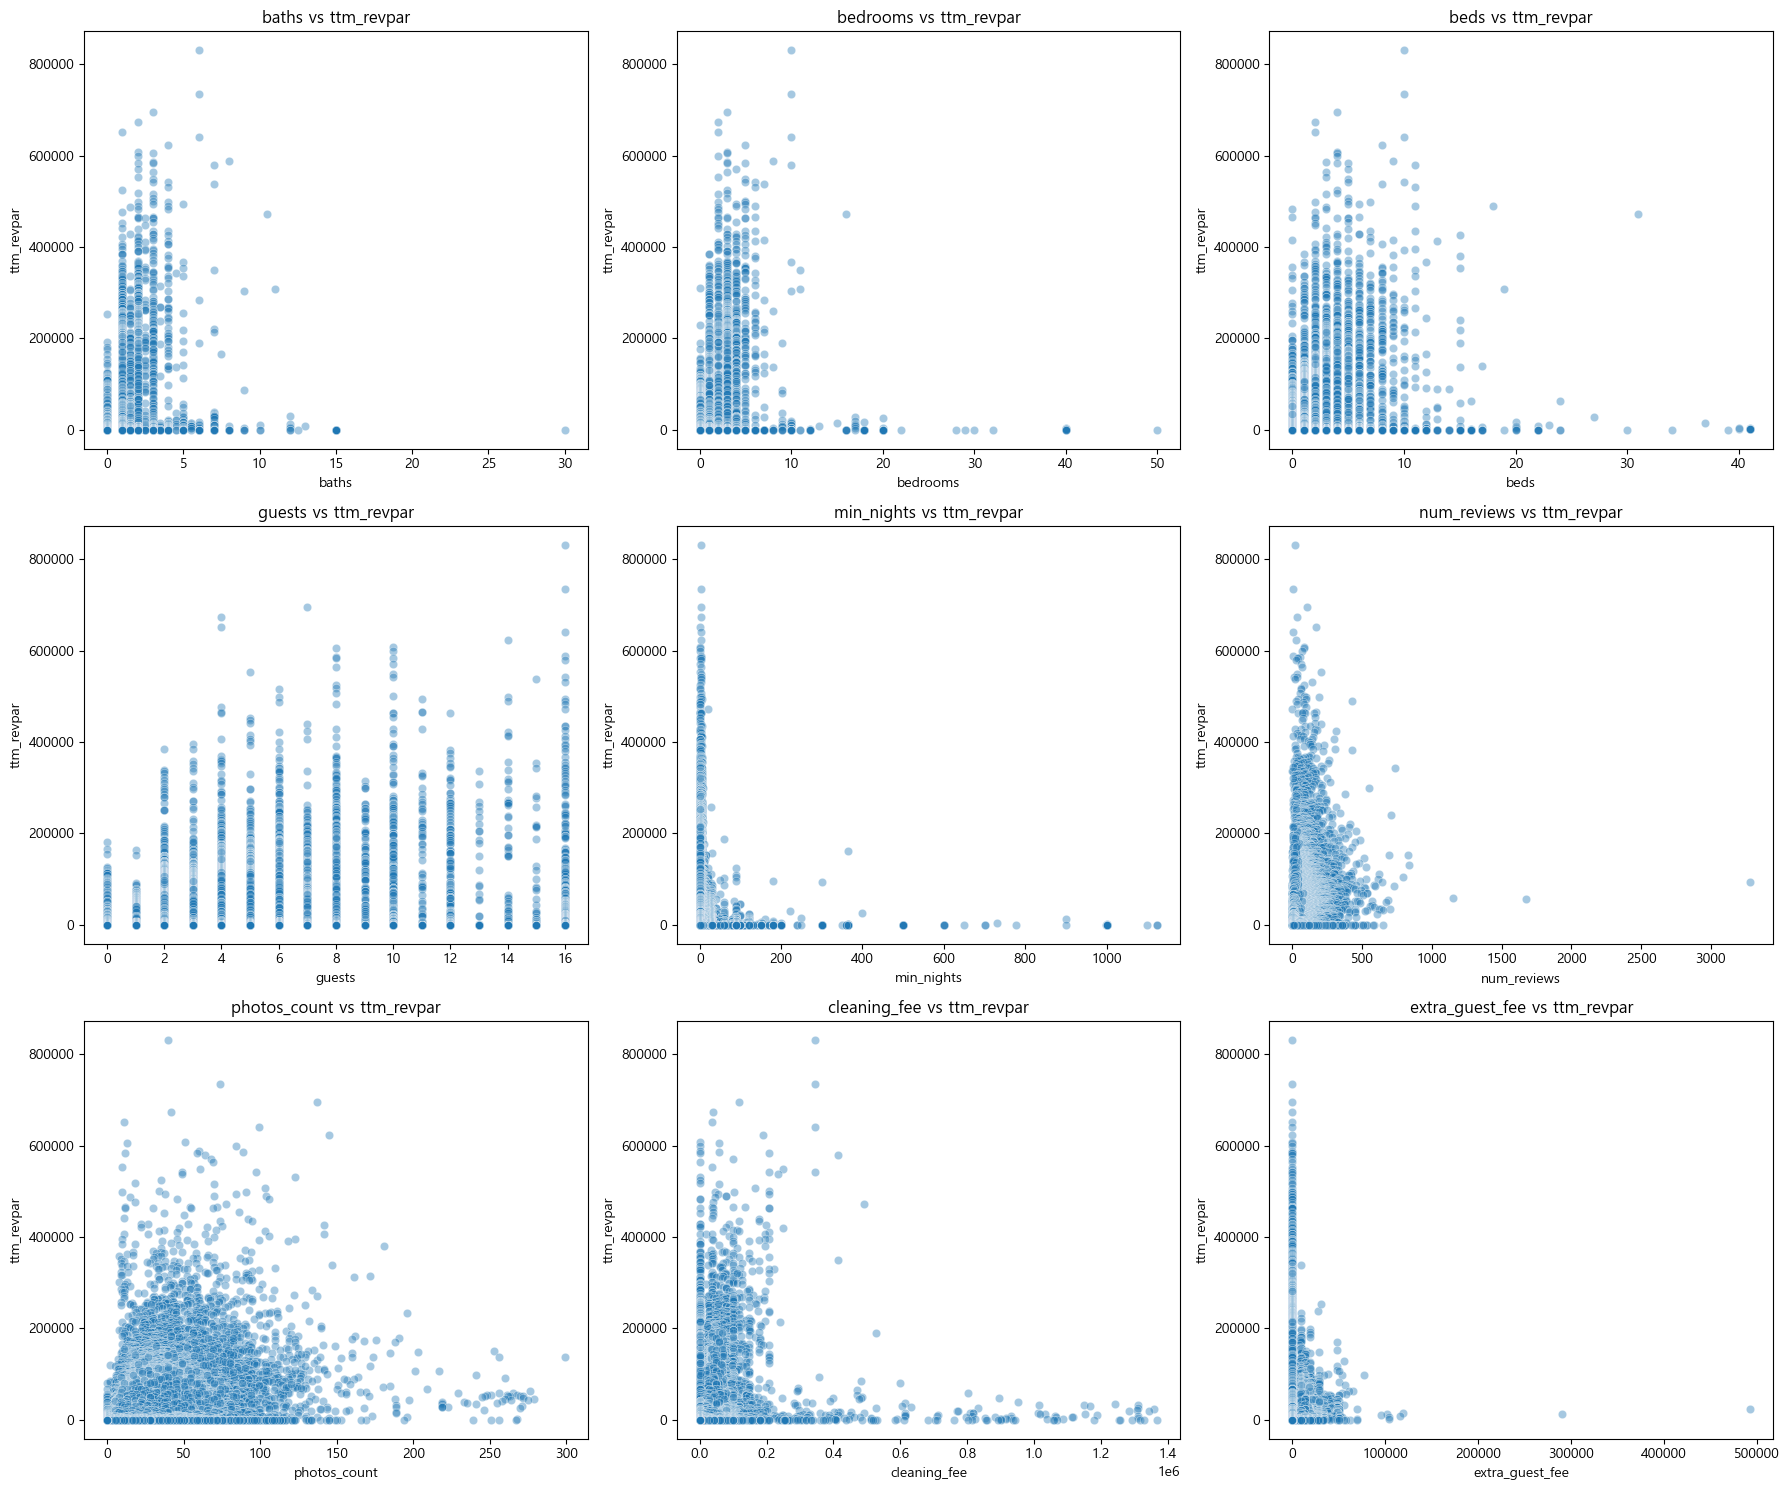

In [457]:
columns_to_check = ['baths', 'bedrooms', 'beds', 'guests',
                    'min_nights', 'num_reviews', 'photos_count',
                    'cleaning_fee', 'extra_guest_fee']

y_col = 'ttm_revpar'

# subplot 행/열 자동 계산
n_cols = 3  # 한 줄에 3개씩
n_rows = math.ceil(len(columns_to_check) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(columns_to_check, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(data=df_airbnb, x=col, y=y_col, alpha=0.4)
    plt.title(f'{col} vs {y_col}')
    plt.tight_layout()

plt.show()

In [458]:
# 제거 전 행 개수
before_rows = len(df_airbnb)

df_airbnb = df_airbnb[df_airbnb['baths'] < 15]
df_airbnb = df_airbnb[df_airbnb['bedrooms'] <= 20]
df_airbnb = df_airbnb[df_airbnb['min_nights'] <= 365] # 최소 숙박 일년 이상 삭제(일년 예약 가능하면 사실상 계속 예약할 수 있음.) 
df_airbnb = df_airbnb[df_airbnb['num_reviews'] < 1000]
df_airbnb = df_airbnb[df_airbnb['extra_guest_fee'] < 200000]

columns_to_check = ['baths', 'bedrooms', 'beds', 'guests',
                    'min_nights', 'num_reviews', 'photos_count']

# 각 컬럼별로 고유값이 1개인 행 제거
for col in columns_to_check:
    counts = df_airbnb[col].value_counts()           # 값별 등장 횟수
    rare_values = counts[counts == 1].index.tolist() # 1개인 값
    df_airbnb = df_airbnb[~df_airbnb[col].isin(rare_values)] # 제거

# 제거 후 행 개수
after_rows = len(df_airbnb)

print(f"제거 전 행 개수: {before_rows}")
print(f"제거 후 행 개수: {after_rows}")
print(f"제거된 데이터 개수: {(before_rows - after_rows)}")
print(f"제거된 데이터 비율: {round((before_rows - after_rows)/before_rows * 100, )} %")

제거 전 행 개수: 32101
제거 후 행 개수: 31845
제거된 데이터 개수: 256
제거된 데이터 비율: 1 %


In [459]:
df_airbnb = df_airbnb[~((df_airbnb['ttm_avg_rate'] == 0) & (df_airbnb['ttm_revenue'] == 0))]
print(f"제거 후 행 개수: {len(df_airbnb)}")

제거 후 행 개수: 28172


In [460]:
df_airbnb = df_airbnb.reset_index(drop=True)
df_airbnb

,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,l90d_avg_rate,...,superhost,ttm_avg_rate,ttm_occupancy,ttm_revenue,ttm_revpar,district,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,6.00,10,10,345745,South Korea,KRW,0,16,False,1202483.26,...,True,1200588.83,0.70,303017921.00,830186.10,서대문구,126.92,37.57,948882.83,1952301.31
1,6.00,10,10,345745,South Korea,KRW,0,16,False,1061610.86,...,True,1155707.69,0.64,267821366.00,733757.20,중구,126.99,37.56,954608.11,1950861.31
2,3.00,3,4,117553,South Korea,KRW,0,7,True,861940.18,...,True,844533.19,0.84,253599755.00,694793.80,종로구,126.99,37.58,954615.93,1953510.22
3,2.00,2,2,38723,South Korea,KRW,0,4,False,1036431.84,...,True,993005.16,0.69,246109671.00,674273.10,성동구,127.04,37.55,958988.32,1950555.43
4,1.00,2,2,37340,South Korea,KRW,0,4,False,637032.61,...,True,722760.07,0.90,237743764.00,651352.80,종로구,126.99,37.58,954973.35,1953045.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28167,1.00,1,1,0,South Korea,KRW,0,1,False,0.00,...,False,21242.56,0.00,0.00,0.00,강남구,127.04,37.53,959405.20,1947657.55
28168,1.00,1,1,0,South Korea,KRW,0,1,False,0.00,...,False,15818.16,0.00,0.00,0.00,종로구,127.02,37.58,957353.02,1953141.66
28169,1.00,1,1,0,South Korea,KRW,0,4,False,127495.81,...,False,121184.27,0.00,0.00,0.00,노원구,127.06,37.63,961158.08,1959350.96
28170,1.00,1,1,0,South Korea,KRW,0,2,False,0.00,...,True,136657.87,0.00,0.00,0.00,중구,126.97,37.55,953338.06,1950625.02


In [461]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료", "서울시 상권분석서비스(영역-자치구)")  # 가공 데이터 저장 폴더
DATA_DIR = os.path.join(FOLDER_DIR, "서울시 상권분석서비스(영역-자치구).shp") 

gdf_gu = gpd.read_file(DATA_DIR) # 장소 경계 벡터 파일(shp)을 GeoDataFrame으로 읽기

gdf_gu_5179 = gdf_gu.to_crs(epsg=5179)
gdf_gu_5179.head(2)

,SIGNGU_CD,SIGNGU_NM,XCNTS_VALU,YDNTS_VALU,RELM_AR,geometry
0,11110,종로구,197997.00,455039.00,23990643.00,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
1,11140,중구,199639.00,451178.00,9990317.00,"POLYGON ((957890.386 1952616.746, 957909.908 1..."


In [462]:
gdf_airbnb_5179 = gpd.GeoDataFrame(
    df_airbnb.copy(),
    geometry=gpd.points_from_xy(
        df_airbnb["X좌표(GRS80TM)"],
        df_airbnb["Y좌표(GRS80TM)"]
    ),
    crs="EPSG:5179"   # 🔥 이미 5179이므로 바로 지정
)

gdf_airbnb_joined = gpd.sjoin(
    gdf_airbnb_5179,
    gdf_gu_5179[["SIGNGU_NM", "geometry"]],
    how="left",
    predicate="within"
)

# 1. district 덮어쓰기
gdf_airbnb_joined["district"] = gdf_airbnb_joined["SIGNGU_NM"]

# 2. 불필요 컬럼 제거
gdf_airbnb_joined = gdf_airbnb_joined.drop(columns=["SIGNGU_NM", "index_right"], errors="ignore")

In [463]:
df_airbnb = gdf_airbnb_joined.copy()
df_airbnb

,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,l90d_avg_rate,...,ttm_avg_rate,ttm_occupancy,ttm_revenue,ttm_revpar,district,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,6.00,10,10,345745,South Korea,KRW,0,16,False,1202483.26,...,1200588.83,0.70,303017921.00,830186.10,서대문구,126.92,37.57,948882.83,1952301.31,POINT (948882.829 1952301.314)
1,6.00,10,10,345745,South Korea,KRW,0,16,False,1061610.86,...,1155707.69,0.64,267821366.00,733757.20,중구,126.99,37.56,954608.11,1950861.31,POINT (954608.11 1950861.305)
2,3.00,3,4,117553,South Korea,KRW,0,7,True,861940.18,...,844533.19,0.84,253599755.00,694793.80,종로구,126.99,37.58,954615.93,1953510.22,POINT (954615.93 1953510.217)
3,2.00,2,2,38723,South Korea,KRW,0,4,False,1036431.84,...,993005.16,0.69,246109671.00,674273.10,성동구,127.04,37.55,958988.32,1950555.43,POINT (958988.316 1950555.435)
4,1.00,2,2,37340,South Korea,KRW,0,4,False,637032.61,...,722760.07,0.90,237743764.00,651352.80,종로구,126.99,37.58,954973.35,1953045.42,POINT (954973.35 1953045.419)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28167,1.00,1,1,0,South Korea,KRW,0,1,False,0.00,...,21242.56,0.00,0.00,0.00,강남구,127.04,37.53,959405.20,1947657.55,POINT (959405.198 1947657.547)
28168,1.00,1,1,0,South Korea,KRW,0,1,False,0.00,...,15818.16,0.00,0.00,0.00,종로구,127.02,37.58,957353.02,1953141.66,POINT (957353.024 1953141.664)
28169,1.00,1,1,0,South Korea,KRW,0,4,False,127495.81,...,121184.27,0.00,0.00,0.00,노원구,127.06,37.63,961158.08,1959350.96,POINT (961158.079 1959350.959)
28170,1.00,1,1,0,South Korea,KRW,0,2,False,0.00,...,136657.87,0.00,0.00,0.00,용산구,126.97,37.55,953338.06,1950625.02,POINT (953338.065 1950625.021)


## 수도권 지하철

In [464]:

df_subway_station = pd.read_csv('병합완료/clean/도시철도역사정보_수도권_GTX추가.csv')
df_subway_station.isnull().sum()

역번호               0
역사명               0
노선번호              0
노선명               0
환승역구분             0
환승노선명           399
역사도로명주소           0
X좌표(WGS84)        0
Y좌표(WGS84)        0
X좌표(GRS80TM)      0
Y좌표(GRS80TM)      0
dtype: int64

In [465]:
# 일반역은 환승 노선명 null 이며 해당 데이터는 프로젝트 목적에 불필요한 데이터여서 삭제
df_subway_station = df_subway_station[['역번호', '역사명', '노선번호', '노선명', '환승역구분', '역사도로명주소', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)']]

# 중복 데이터 삭제
df_subway_clean = df_subway_station.drop_duplicates(
    subset=['역사명', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)'],
    keep='first'
)

df_subway_clean = df_subway_clean.reset_index(drop=True)
df_subway_clean

,역번호,역사명,노선번호,노선명,환승역구분,역사도로명주소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,0124,청량리(서울시립대입구),I4101,1호선,환승역,서울특별시 동대문구 왕산로 지하205(전농동),127.05,37.58,959831.00,1953515.47
1,0125,제기동,I4101,1호선,일반역,서울특별시 동대문구 왕산로 지하93(제기동),127.03,37.58,958932.70,1953294.43
2,0126,신설동,I4101,1호선,환승역,서울특별시 동대문구 왕산로 지하1(신설동),127.02,37.58,958031.64,1953077.15
3,0127,동묘앞,I4101,1호선,환승역,서울특별시 종로구 종로 359(숭인동),127.02,37.57,957301.44,1952764.45
4,0128,동대문,I4101,1호선,환승역,서울특별시 종로구 종로 지하302(창신동),127.01,37.57,956791.07,1952587.47
...,...,...,...,...,...,...,...,...,...,...
599,X105,서울역,GTX-A,GTX,환승역,서울특별시 용산구 한강대로 405,126.97,37.55,953260.87,1950728.91
600,X106,수서역,GTX-A,GTX,환승역,서울특별시 강남구 광평로 지하270,127.10,37.49,964809.60,1943152.25
601,X107,성남역,GTX-A,GTX,환승역,경기도 성남시 분당구 백현동 545-1,127.12,37.39,966315.39,1932914.54
602,X108,구성역,GTX-A,GTX,환승역,경기도 용인시 기흥구 용구대로 2403,127.11,37.30,965041.57,1922256.99


## 버스 노선별 정류소 맵핑
- 노선별이어서 중복 노선 및 정류소가 있을 수 밖에 없음

In [466]:
df_bus_route = pd.read_csv('병합완료/clean/버스노선_정류소매핑_20260108.csv')
df_bus_route.isnull().sum()

ROUTE_ID        0
노선명             0
순번              0
NODE_ID         0
ARS_ID          0
정류소명            0
X좌표(WGS84)      0
Y좌표(WGS84)      0
X좌표(GRS80TM)    0
Y좌표(GRS80TM)    0
dtype: int64

In [467]:
df_bus_route

,ROUTE_ID,노선명,순번,NODE_ID,ARS_ID,정류소명,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,121900012,서초15,1,121900003,22227,롯데캐슬헤론아파트,126.99,37.50,954495.38,1944348.36
1,121900007,서초09,1,121900005,22343,헌인가구단지,127.09,37.46,963448.58,1940134.20
2,121900005,서초03,1,121900007,22345,교대역5번출구,127.01,37.49,957103.89,1943949.00
3,121900006,서초11,1,121900008,22267,예술의전당,127.01,37.48,956972.81,1942465.26
4,121900003,서초10,1,121900011,22380,서초구민체육센터,126.99,37.50,954947.07,1944468.80
...,...,...,...,...,...,...,...,...,...,...
12884,100100039,202,127,222001504,42404,화접초등학교.별내고등학교,127.12,37.65,966126.37,1961440.58
12885,100100522,2016,127,106000140,7235,면목마젤란아파트,127.08,37.59,963267.54,1954227.05
12886,100100522,2016,128,106000228,7324,아남리치카운티아파트,127.09,37.59,963396.12,1954636.96
12887,100100039,202,128,222000588,49894,별빛마을3단지.신안인스빌정문,127.11,37.65,965962.89,1961219.89


## 버스 정류소 위치 데이터

In [468]:
df_bus_station = pd.read_csv('병합완료/clean/버스정류소_위치정보_20260108.csv')
df_bus_station.isnull().sum()

NODE_ID         0
ARS_ID          0
정류소명            0
정류소타입           0
X좌표(WGS84)      0
Y좌표(WGS84)      0
X좌표(GRS80TM)    0
Y좌표(GRS80TM)    0
dtype: int64

In [469]:
duplicates = df_bus_station[
    df_bus_station.duplicated(subset=['정류소명', "X좌표(WGS84)", "Y좌표(WGS84)"], keep=False)
]

duplicates

,NODE_ID,ARS_ID,정류소명,정류소타입,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)


In [470]:
# 중복 데이터 삭제
df_bus_station_clean = df_bus_station.drop_duplicates(
    subset=['정류소명', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)'],
    keep='first'
)

df_bus_station_clean = df_bus_station_clean.reset_index(drop=True)
df_bus_station_clean

,NODE_ID,ARS_ID,정류소명,정류소타입,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,118000622,5,한강버스.여의도선착장,한강선착장,126.93,37.53,950044.00,1947894.93
1,113000513,6,한강버스.망원선착장,한강선착장,126.89,37.55,946496.08,1950765.09
2,115000952,7,한강버스.마곡선착장,한강선착장,126.84,37.58,942077.44,1953060.36
3,100000001,1001,종로2가사거리,중앙차로,126.99,37.57,954764.41,1952394.08
4,100000002,1002,창경궁.서울대학교병원,중앙차로,127.00,37.58,955544.46,1953458.00
...,...,...,...,...,...,...,...,...
11230,124000334,25995,천호우성아파트,일반차로,127.14,37.55,968142.49,1950177.38
11231,124000333,25996,천호우성아파트,일반차로,127.14,37.55,968205.12,1950205.64
11232,124000332,25997,라움포레아파트,일반차로,127.12,37.53,966744.50,1948323.91
11233,124000331,25998,성내시장,일반차로,127.13,37.54,966913.54,1948603.34


In [471]:
df_bus_station_clean[df_bus_station_clean['정류소명'] == '명일동국민은행.래미안솔베뉴']

,NODE_ID,ARS_ID,정류소명,정류소타입,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
11117,124900009,25545,명일동국민은행.래미안솔베뉴,마을버스,127.14,37.55,968570.42,1950546.66
11193,124900047,25674,명일동국민은행.래미안솔베뉴,마을버스,127.14,37.55,968587.28,1950506.96
11227,124000435,25783,명일동국민은행.래미안솔베뉴,일반차로,127.14,37.55,968572.66,1950592.77


In [472]:
# 'X좌표(WGS84)','Y좌표(WGS84)'값이 같아보여도 실제로는 다른 값임.
# 그래서 X좌표(GRS80TM)	Y좌표(GRS80TM) 값이 다 다름.
print(df_bus_station_clean[['X좌표(WGS84)','Y좌표(WGS84)']].map(lambda x: f"{float(x):.10f}"))

           X좌표(WGS84)     Y좌표(WGS84)
0      126.9346070000  37.5290100000
1      126.8942450000  37.5546800000
2      126.8440400000  37.5751000000
3      126.9877522923  37.5698055407
4      126.9965206101  37.5794329320
...               ...            ...
11230  127.1393385419  37.5503857320
11231  127.1400463819  37.5506426076
11232  127.1235961820  37.5336302630
11233  127.1254968434  37.5361549340
11234  127.1273370925  37.5403430618

[11235 rows x 2 columns]


In [473]:
# 두 데이터프레임 세로 결합 (컬럼 다르면 자동으로 NaN 채움)
df_bus_station_merged = pd.concat([df_bus_station_clean, df_bus_route], ignore_index=True)

# 정류소명 기준 중복 제거 (첫 번째 값 유지)
df_bus_station_merged = df_bus_station_merged.drop_duplicates(subset='정류소명', keep='first')
df_bus_station_merged = df_bus_station_merged.reset_index(drop=True)
df_bus_station_merged = df_bus_station_merged[['NODE_ID', 'ARS_ID', '정류소명', '정류소타입', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)']]
df_bus_station_merged

,NODE_ID,ARS_ID,정류소명,정류소타입,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,118000622,5,한강버스.여의도선착장,한강선착장,126.93,37.53,950044.00,1947894.93
1,113000513,6,한강버스.망원선착장,한강선착장,126.89,37.55,946496.08,1950765.09
2,115000952,7,한강버스.마곡선착장,한강선착장,126.84,37.58,942077.44,1953060.36
3,100000001,1001,종로2가사거리,중앙차로,126.99,37.57,954764.41,1952394.08
4,100000002,1002,창경궁.서울대학교병원,중앙차로,127.00,37.58,955544.46,1953458.00
...,...,...,...,...,...,...,...,...
8514,210000076,46097,송내초교.법원입구,NaN,126.76,37.49,934601.72,1943660.86
8515,205000045,49047,남한산성공원입구.양지파출소,NaN,127.17,37.46,970760.99,1940410.33
8516,210000086,46605,복사골문화센터.부천시청소년센,NaN,126.75,37.49,934040.39,1944139.72
8517,204000012,48611,민속마을.선경아파트,NaN,127.16,37.46,969563.79,1940421.13


## 서울시_문화행사정보

In [474]:
df_festival = pd.read_csv('./병합완료/clean/서울시_문화행사정보_2025.csv')
df_festival.isnull().sum()

분류                 0
자치구               16
공연/행사명             0
날짜                 0
장소                 0
기관명                0
이용대상               0
이용요금            1997
문의                 0
출연자정보           3109
프로그램소개          3092
기타내용            3534
홈페이지?주소            0
대표이미지              0
신청일                0
시민/기관              0
시작일                0
종료일                0
테마분류               5
유무료                0
문화포털상세URL          0
행사시간               0
X좌표(WGS84)         1
Y좌표(WGS84)         2
X좌표(GRS80TM)       2
Y좌표(GRS80TM)       2
dtype: int64

In [475]:
df_festival.head(1)

,분류,자치구,공연/행사명,날짜,장소,기관명,이용대상,이용요금,문의,출연자정보,...,시작일,종료일,테마분류,유무료,문화포털상세URL,행사시간,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,기타,광진구,[미래한강본부] 2025 한강공원 눈썰매장 개장,2025-12-31~2026-02-28,"뚝섬, 잠원, 여의도",미래한강본부,누구나,"6,000원(모든 연령)",뚝섬 02-452-5955 / 잠원 02-536-8263 / 여의도 02-785-0478,NaN,...,2025.12.31 0:00,2026.2.28 0:00,기타,유료,https://culture.seoul.go.kr/culture/culture/cu...,10:00~17:00 (노면정비 시간: 오후 1시~오후 2시에는 슬로프 이용 불가),127.07,37.53,962358.56,1947869.36


In [476]:
df_festival.columns

Index(['분류', '자치구', '공연/행사명', '날짜', '장소', '기관명', '이용대상', '이용요금', '문의', '출연자정보',
       '프로그램소개', '기타내용', '홈페이지?주소', '대표이미지', '신청일', '시민/기관', '시작일', '종료일',
       '테마분류', '유무료', '문화포털상세URL', '행사시간', 'X좌표(WGS84)', 'Y좌표(WGS84)',
       'X좌표(GRS80TM)', 'Y좌표(GRS80TM)'],
      dtype='object')

In [477]:
df_festival = df_festival[['분류', '자치구', '공연/행사명', '날짜', '장소', '기관명', '시작일', '종료일',
                           'X좌표(WGS84)', 'Y좌표(WGS84)','X좌표(GRS80TM)', 'Y좌표(GRS80TM)']]

df_festival.isnull().sum()

분류               0
자치구             16
공연/행사명           0
날짜               0
장소               0
기관명              0
시작일              0
종료일              0
X좌표(WGS84)       1
Y좌표(WGS84)       2
X좌표(GRS80TM)     2
Y좌표(GRS80TM)     2
dtype: int64

In [478]:
df_festival.loc[df_festival['자치구'].isnull(), ['자치구', '장소', '기관명']]

,자치구,장소,기관명
758,NaN,서울대공원 만남의 광장 일대,서울대공원
2449,NaN,"테마가든 장미원, 식물원",서울대공원
2537,NaN,서울어린이대공원 열린무대,광진문화재단
2594,NaN,서울어린이대공원 숲속의무대,광진문화재단
2747,NaN,서울대공원 동물원 일대,서울대공원
3127,NaN,서울대공원 일대,서울대공원
3179,NaN,서울동물원,서울대공원
3180,NaN,서울동물원,서울대공원
3181,NaN,각 기관,서울대공원
3182,NaN,각 기관,서울대공원


In [479]:
# 자치구가 결측치인 행만 처리
df_festival.loc[
    (df_festival['자치구'].isnull()) & (df_festival['기관명'] == '서울대공원'),
    '자치구'
] = '과천시'

df_festival.loc[
    (df_festival['자치구'].isnull()) & (df_festival['기관명'] == '광진문화재단'),
    '자치구'
] = '광진구'

df_festival.isnull().sum()

분류              0
자치구             0
공연/행사명          0
날짜              0
장소              0
기관명             0
시작일             0
종료일             0
X좌표(WGS84)      1
Y좌표(WGS84)      2
X좌표(GRS80TM)    2
Y좌표(GRS80TM)    2
dtype: int64

In [480]:
# 위도, 경도 null값 처리
df_festival.loc[df_festival['X좌표(GRS80TM)'].isnull(), ['장소', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)']]

,장소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
2423,강서시니어스타운 B1 송도아트홀,NaN,NaN,NaN,NaN
2718,인사동 한국미술관 2층 전시관,126.99,NaN,NaN,NaN


In [481]:
# 1. 섞여있는 이상한 글자(예: '~2')를 지우고, 해당 컬럼들을 강제 '숫자형(Float)'으로 청소합니다.
coords_cols = ['X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)']
for col in coords_cols:
    df_festival[col] = pd.to_numeric(df_festival[col], errors='coerce')

# 2. 이제 컬럼이 숫자형이 되었으므로, 순수한 숫자를 넣어도 에러가 나지 않습니다!
df_festival.loc[
    df_festival['장소'] == '강서시니어스타운 B1 송도아트홀', 
    ['X좌표(WGS84)', 'Y좌표(WGS84)']
] = [126.859331, 37.556983]

# 3. 좌표 오표기 수정
df_festival.loc[
    df_festival['장소'] == '인사동 한국미술관 2층 전시관', 
    ['Y좌표(WGS84)']
] = [37.5718961547884]

In [482]:
df_festival.loc[df_festival['X좌표(GRS80TM)'].isnull(), ['장소', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)']]

,장소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
2423,강서시니어스타운 B1 송도아트홀,126.86,37.56,NaN,NaN
2718,인사동 한국미술관 2층 전시관,126.99,37.57,NaN,NaN


In [483]:
from pyproj import Transformer

# WGS84 → GRS80TM (EPSG:4326 -> EPSG:5179)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:5179", always_xy=True)

# X좌표(GRS80TM)가 NaN인 행만 선택
mask = df_festival["X좌표(GRS80TM)"].isnull()

# 변환 (경도, 위도 순)
xs, ys = transformer.transform(
    df_festival.loc[mask, "X좌표(WGS84)"].to_numpy(),
    df_festival.loc[mask, "Y좌표(WGS84)"].to_numpy()
)

# 변환된 값으로 GRS80TM 좌표 컬럼 업데이트
df_festival.loc[mask, "X좌표(GRS80TM)"] = xs
df_festival.loc[mask, "Y좌표(GRS80TM)"] = ys

df_festival.isnull().sum()

분류              0
자치구             0
공연/행사명          0
날짜              0
장소              0
기관명             0
시작일             0
종료일             0
X좌표(WGS84)      0
Y좌표(WGS84)      0
X좌표(GRS80TM)    0
Y좌표(GRS80TM)    0
dtype: int64

In [484]:
display(df_airbnb.head(2), df_subway_clean.head(2),
        df_bus_station_merged.head(2), df_festival.head(2))

,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,l90d_avg_rate,...,ttm_avg_rate,ttm_occupancy,ttm_revenue,ttm_revpar,district,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,6.00,10,10,345745,South Korea,KRW,0,16,False,1202483.26,...,1200588.83,0.70,303017921.00,830186.10,서대문구,126.92,37.57,948882.83,1952301.31,POINT (948882.829 1952301.314)
1,6.00,10,10,345745,South Korea,KRW,0,16,False,1061610.86,...,1155707.69,0.64,267821366.00,733757.20,중구,126.99,37.56,954608.11,1950861.31,POINT (954608.11 1950861.305)


,역번호,역사명,노선번호,노선명,환승역구분,역사도로명주소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,0124,청량리(서울시립대입구),I4101,1호선,환승역,서울특별시 동대문구 왕산로 지하205(전농동),127.05,37.58,959831.00,1953515.47
1,0125,제기동,I4101,1호선,일반역,서울특별시 동대문구 왕산로 지하93(제기동),127.03,37.58,958932.70,1953294.43


,NODE_ID,ARS_ID,정류소명,정류소타입,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,118000622,5,한강버스.여의도선착장,한강선착장,126.93,37.53,950044.00,1947894.93
1,113000513,6,한강버스.망원선착장,한강선착장,126.89,37.55,946496.08,1950765.09


,분류,자치구,공연/행사명,날짜,장소,기관명,시작일,종료일,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM)
0,기타,광진구,[미래한강본부] 2025 한강공원 눈썰매장 개장,2025-12-31~2026-02-28,"뚝섬, 잠원, 여의도",미래한강본부,2025.12.31 0:00,2026.2.28 0:00,127.07,37.53,962358.56,1947869.36
1,연극,종로구,연극 [잔류자들],2025-12-31~2026-01-04,선돌극장,기타,2025.12.31 0:00,2026.1.4 0:00,127.00,37.59,955835.30,1954275.21


# CSV 파일 저장 

In [485]:
import os
import pandas as pd

# 1. 파일들을 한데 모아둘 저장 폴더 생성
save_dir = './완전최종_전처리완료_CSV모음'
os.makedirs(save_dir, exist_ok=True)

# 2. [변수명 : 저장할 파일명] 딕셔너리 세팅
df_mapping = {
    # === 재희 ===
    "df_police": "치안센터.csv",
    "df_rroom": "공중화장실.csv",
    "df_cctv_final": "cctv.csv",
    "gdf_subway_final": "지하철_유동인구.csv",
    "gdf_time_subway_final": "지하철_시간대별평균유동인구.csv",
    "df_commerce_final": "상권_유동인구_직장인구_상주인구_상권변화지표.csv",

    # === 동주 ===
    "gdf_landmark_5179": "서울시_관광_명소_보완.csv",
    "gdf_120_place_5179": "서울시_주요_120장소_목록.csv",
    "gdf_park_5179": "서울시_주요_공원.csv",
    "df_search_rank": "카테고리별_검색순위.csv",
    "df_keyword": "키워드별_언급량.csv",
    "df_kor_tour_country_2025": "한국관광관련_국가별_언급량_인게이지먼트_잠재적_노출량.csv",
    "df_kor_tour_mention": "한국관광관련_언급량_인게이지먼트_추이.csv",

    # === 진원 ===
    "hotel_cleaned_5179": "서울시_관광숙박업_인허가_정보.csv",
    "motel_subset_5179": "서울시_일반숙박업_인허가_정보.csv",
    "native_foreigner": "자치구별_내외국인_방문자_수_추이.csv",
    "stay": "자치구별_숙박방문외지인_숙박_체류시간_월별데이터.csv",

    # === 지섭 ===
    "df_airbnb": "에어비앤비.csv",
    "df_subway_clean": "지하철역사정보.csv",
    "df_bus_station_merged": "버스정류소_위치정보.csv",
    "df_festival": "서울시_문화행사정보.csv"
}

# 3. 매핑된 딕셔너리를 돌면서 CSV로 자동 저장
saved_count = 0
missing_vars = []

print(f"📂 저장 경로: {os.path.abspath(save_dir)}\n" + "="*50)

for var_name, file_name in df_mapping.items():
    # globals() 또는 locals()에서 해당 변수명이 존재하는지 확인
    if var_name in globals() or var_name in locals():
        # 변수명으로 실제 데이터프레임 객체 가져오기
        df_to_save = globals().get(var_name, locals().get(var_name))
        
        # 파일 경로 설정 및 저장 (한글 깨짐 방지를 위해 utf-8-sig 사용)
        file_path = os.path.join(save_dir, file_name)
        df_to_save.to_csv(file_path, index=False, encoding='utf-8-sig')
        
        print(f"✅ 저장 완료: {file_name} (변수: {var_name}, 크기: {df_to_save.shape})")
        saved_count += 1
    else:
        missing_vars.append(var_name)

# 4. 최종 결과 리포트
print("="*50)
print(f"🎉 총 {saved_count}개의 파일이 성공적으로 저장되었습니다!")

if missing_vars:
    print(f"⚠️ [주의] 아래 {len(missing_vars)}개의 변수는 현재 노트북에 실행/정의되어 있지 않아 건너뛰었습니다.")
    for mv in missing_vars:
        print(f"   - {mv}")

📂 저장 경로: c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)\완전최종_전처리완료_CSV모음
✅ 저장 완료: 치안센터.csv (변수: df_police, 크기: (55, 10))
✅ 저장 완료: 공중화장실.csv (변수: df_rroom, 크기: (4451, 8))
✅ 저장 완료: cctv.csv (변수: df_cctv_final, 크기: (25, 6))
✅ 저장 완료: 지하철_유동인구.csv (변수: gdf_subway_final, 크기: (5580, 14))
✅ 저장 완료: 지하철_시간대별평균유동인구.csv (변수: gdf_time_subway_final, 크기: (5592, 32))
✅ 저장 완료: 상권_유동인구_직장인구_상주인구_상권변화지표.csv (변수: df_commerce_final, 크기: (4941, 62))
✅ 저장 완료: 서울시_관광_명소_보완.csv (변수: gdf_landmark_5179, 크기: (507, 8))
✅ 저장 완료: 서울시_주요_120장소_목록.csv (변수: gdf_120_place_5179, 크기: (120, 4))
✅ 저장 완료: 서울시_주요_공원.csv (변수: gdf_park_5179, 크기: (131, 8))
✅ 저장 완료: 카테고리별_검색순위.csv (변수: df_search_rank, 크기: (31623, 9))
✅ 저장 완료: 키워드별_언급량.csv (변수: df_keyword, 크기: (120, 6))
✅ 저장 완료: 한국관광관련_국가별_언급량_인게이지먼트_잠재적_노출량.csv (변수: df_kor_tour_country_2025, 크기: (20, 4))
✅ 저장 완료: 한국관광관련_언급량_인게이지먼트_추이.csv (변수: df_kor_tour_mention, 크기: (12, 10))
✅ 저장 완료: 서울시_관광숙박업_인허가_정보.csv (변수: hotel_cleaned_5179, 크기: (592, 11))
✅ 저장 완료: 서울시_일반숙박업_인허가

In [486]:
# 1. GPKG를 모아둘 폴더 생성
save_dir_gpkg = './완전최종_전처리완료_GPKG모음'
os.makedirs(save_dir_gpkg, exist_ok=True)

# 2. [변수명 : 파일명] 딕셔너리 (아까와 동일하지만 저장 시 확장자를 gpkg로 바꿀 예정입니다)
df_mapping = {
    # === 재희 ===
    "df_police": "치안센터.gpkg",
    "df_rroom": "공중화장실.gpkg",
    "df_cctv_final": "cctv.gpkg",
    "gdf_subway_final": "지하철_유동인구.gpkg",
    "gdf_time_subway_final": "지하철_시간대별평균유동인구.gpkg",
    "df_commerce_final": "상권_유동인구_직장인구_상주인구_상권변화지표.gpkg",

    # === 동주 ===
    "gdf_landmark_5179": "서울시_관광_명소_보완.gpkg",
    "gdf_120_place_5179": "서울시_주요_120장소_목록.gpkg",
    "gdf_park_5179": "서울시_주요_공원.gpkg",
    "df_search_rank": "카테고리별_검색순위.gpkg",
    "df_keyword": "키워드별_언급량.gpkg",
    "df_kor_tour_country_2025": "한국관광관련_국가별_언급량_인게이지먼트_잠재적_노출량.gpkg",
    "df_kor_tour_mention": "한국관광관련_언급량_인게이지먼트_추이.gpkg",

    # === 진원 ===
    "hotel_cleaned_5179": "서울시_관광숙박업_인허가_정보.gpkg",
    "motel_subset_5179": "서울시_일반숙박업_인허가_정보.gpkg",
    "native_foreigner": "자치구별_내외국인_방문자_수_추이.gpkg",
    "stay": "자치구별_숙박방문외지인_숙박_체류시간_월별데이터.gpkg",

    # === 지섭 ===
    "df_airbnb": "에어비앤비.gpkg",
    "df_subway_clean": "지하철역사정보.gpkg",
    "df_bus_station_merged": "버스정류소_위치정보.gpkg",
    "df_festival": "서울시_문화행사정보.gpkg"
}

saved_count = 0
skipped_vars = []

print(f"📂 GPKG 저장 경로: {os.path.abspath(save_dir_gpkg)}\n" + "="*60)

for var_name, file_name in df_mapping.items():
    if var_name in globals() or var_name in locals():
        df_to_save = globals().get(var_name, locals().get(var_name))
        file_path = os.path.join(save_dir_gpkg, file_name)
        
        try:
            # 케이스 1: 이미 GeoDataFrame인 경우 (바로 저장)
            if isinstance(df_to_save, gpd.GeoDataFrame):
                df_to_save.to_file(file_path, driver="GPKG", encoding='utf-8')
                print(f"✅ [GPKG 저장 성공] {file_name}")
                saved_count += 1
                
            # 케이스 2: 일반 DataFrame이지만 X, Y 좌표(GRS80TM)가 있는 경우 (변환 후 저장)
            elif 'X좌표(GRS80TM)' in df_to_save.columns and 'Y좌표(GRS80TM)' in df_to_save.columns:
                # 좌표를 이용해 geometry 생성
                gdf = gpd.GeoDataFrame(
                    df_to_save, 
                    geometry=gpd.points_from_xy(df_to_save['X좌표(GRS80TM)'], df_to_save['Y좌표(GRS80TM)']),
                    crs="EPSG:5179" # GRS80TM 좌표계 지정
                )
                gdf.to_file(file_path, driver="GPKG", encoding='utf-8')
                print(f"✅ [좌표 변환 -> GPKG 저장 성공] {file_name}")
                saved_count += 1
                
            # 케이스 3: 좌표도 없고 공간 데이터도 아닌 경우 (에러를 내서 except로 넘김)
            else:
                raise ValueError("공간 정보 없음")
                
        except Exception as e:
            # 에러가 나면 프로그램이 멈추지 않고 여기로 와서 패스합니다.
            print(f"⏩ [건너뜀 패스] {file_name} (사유: 공간 좌표가 없거나 변환 불가)")
            skipped_vars.append(var_name)

print("="*60)
print(f"🎉 총 {saved_count}개의 공간 데이터가 GPKG로 성공적으로 저장되었습니다!")
if skipped_vars:
    print(f"💡 일반 텍스트 데이터라서 건너뛴 항목: {len(skipped_vars)}개")

📂 GPKG 저장 경로: c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)\완전최종_전처리완료_GPKG모음
✅ [GPKG 저장 성공] 치안센터.gpkg
✅ [GPKG 저장 성공] 공중화장실.gpkg
✅ [GPKG 저장 성공] cctv.gpkg
✅ [GPKG 저장 성공] 지하철_유동인구.gpkg
✅ [GPKG 저장 성공] 지하철_시간대별평균유동인구.gpkg
✅ [GPKG 저장 성공] 상권_유동인구_직장인구_상주인구_상권변화지표.gpkg
✅ [GPKG 저장 성공] 서울시_관광_명소_보완.gpkg
✅ [GPKG 저장 성공] 서울시_주요_120장소_목록.gpkg
✅ [GPKG 저장 성공] 서울시_주요_공원.gpkg
⏩ [건너뜀 패스] 카테고리별_검색순위.gpkg (사유: 공간 좌표가 없거나 변환 불가)
⏩ [건너뜀 패스] 키워드별_언급량.gpkg (사유: 공간 좌표가 없거나 변환 불가)
⏩ [건너뜀 패스] 한국관광관련_국가별_언급량_인게이지먼트_잠재적_노출량.gpkg (사유: 공간 좌표가 없거나 변환 불가)
⏩ [건너뜀 패스] 한국관광관련_언급량_인게이지먼트_추이.gpkg (사유: 공간 좌표가 없거나 변환 불가)
✅ [GPKG 저장 성공] 서울시_관광숙박업_인허가_정보.gpkg
✅ [GPKG 저장 성공] 서울시_일반숙박업_인허가_정보.gpkg
⏩ [건너뜀 패스] 자치구별_내외국인_방문자_수_추이.gpkg (사유: 공간 좌표가 없거나 변환 불가)
⏩ [건너뜀 패스] 자치구별_숙박방문외지인_숙박_체류시간_월별데이터.gpkg (사유: 공간 좌표가 없거나 변환 불가)
✅ [GPKG 저장 성공] 에어비앤비.gpkg
✅ [좌표 변환 -> GPKG 저장 성공] 지하철역사정보.gpkg
✅ [좌표 변환 -> GPKG 저장 성공] 버스정류소_위치정보.gpkg
✅ [좌표 변환 -> GPKG 저장 성공] 서울시_문화행사정보.gpkg
🎉 총 15개의 공간 데이터가 GPKG로 성공적으로 저장되었습니다!
💡 일반 텍스트 데이터라서 건너뛴 